# The latent dimensionality of baryonic feedback in the kSZ — a continuous DESI DR2 $\times$ ACT DR6 confrontation with BIND

### The question this paper answers
> *Across the **entire** space of plausible galaxy-formation feedback, how many
> independent directions actually control the circum-galactic gas that the
> kinetic and thermal Sunyaev–Zel'dovich effects measure — and does the real
> Universe (DESI DR2 $\times$ ACT DR6) live inside that space?*

### Why it could not be asked before — and can now, thanks to BIND
Constraining feedback has been stuck between two regimes. **Hydrodynamic suites**
(IllustrisTNG, EAGLE, SIMBA, the FLAMINGO variants) sample feedback at a *handful of
discrete points* — you cannot differentiate an observable with respect to a feedback
knob, so you cannot ask *which* knobs matter or map a measurement back into the
parameter space. **Baryon-correction models** (BCM) are continuous but carry only
1–7 effective parameters by construction, so they *assume* the answer to the
dimensionality question rather than measuring it.

**BIND removes both limitations at once.** It is a conditional flow-matching emulator
that paints the hydro baryon fields onto a dark-matter-only lightcone as a *smooth,
differentiable function of the full 35-parameter CAMELS-IllustrisTNG vector* (30 of
them astrophysical). We painted a **256-node Sobol sweep** of that 30-d feedback space
onto the TNG300 ($L=205\,h^{-1}$Mpc) DMO lightcone and read off, from each node's painted
per-halo patches, the **electron column $\tau$** (the kSZ leg) and the **Compton-$y$** field
(the tSZ leg). The result is the first object of its kind: *the kSZ/tSZ CGM observables as a
continuous, differentiable function of 30 feedback parameters.* (These are stacked **1-halo**
painted patches at each tracer's lightcone redshift — not a full multi-plane ray-trace; the
2-halo/line-of-sight terms are absent, which is why every comparison is in the 1-halo regime.)

### What we find
1. **The gas response is 2-dimensional.** Projected onto the $\tau$ and $y$ profiles of
   BGS-mass halos, the 30-d feedback response collapses onto a **~2-d latent manifold**
   (97% of the variance in two components; §4). Oriented to physics, the two axes are the
   **inner gas** ($f_{\rm gas}{<}R_{500}$, $r=0.95$ — the wind/SN ejection axis) and the
   **outer gas** ($f_{\rm gas}$ in the $R_{500}{\to}R_{200}$ shell, $r=0.95$; the two zones only
   $r=0.24$ correlated): feedback depletes the core and the outskirts semi-independently.
2. **TNG's fiducial is too gas-rich; the data pin feedback to its strong edge.** In the
   *exact* observable the kSZ survey reports — the **CAP-ratio** $\tilde f_{\rm gas}=
   {\rm CAP}_{\rm gas}/{\rm CAP}_{\rm mat}$ (Ried Guachalla et al. 2025, §6) — the **fiducial
   is $\sim$1.4–1.8$\times$ too gas-rich within $r_{200}$** ($\sim$2$\sigma$), but this is
   **not** beyond TNG's reach: $\sim$20% of the 256 nodes are consistent within today's (large)
   errors, and the data **pin the ejection latent to TNG's strong-feedback edge** — the
   measurement is *feedback/data-limited* (§6, §6e, §7), not "0/256". The **tSZ pressure**, at the
   *correct* DESI-LRG host mass ($\log M{=}13.18\,M_\odot/h$), tells the **same** story ($\sim$1.5$\times$,
   §6d) — though its amplitude is mass-selection-dominated ($Y\!\propto\!M^{5/3}$), so the clean leg is
   the $\sigma_v$-free kSZ ratio; the X-ray eROSITA constraint (§5) is tighter still. Coherent with the
   Siegel/Bigwood missing-baryon consensus.
3. **The forecast (money plot, §8).** The two latents the data *respond* to are
   exactly the two a future SO / CMB-S4 $\times$ DESI kSZ$+$tSZ measurement will
   *pin* — tSZ (pressure) and kSZ (density) being complementary, not redundant.
   BIND is therefore a ready forecasting instrument for the continuous feedback
   inference that next-generation data will enable.

*Citations.* CAMELS: Villaescusa-Navarro et al. (2021). IllustrisTNG: Weinberger et al.
(2017), Pillepich et al. (2018), Nelson et al. (2019, TNG300 public data). DESI tracers:
DESI Collaboration (2024), Hahn et al. (2023, BGS), Zhou et al. (2023, LRG),
Raichoor et al. (2023, ELG). DESI$\times$ACT kSZ: Hadzhiyska et al. (2024),
Ried Guachalla et al. (2025); earlier stacks Schaan et al. (2021), Amodeo et al. (2021).
Strong-feedback / missing-baryon consensus: Bigwood et al. (2025), Kovač et al. (2025,
arXiv:2507.07991), Siegel et al. (2025, arXiv:2509.10455). X-ray $f_{\rm gas}$:
Eckert et al. (2019), Popesso et al. (2024). Low-dimensional feedback latents:
Lin et al. (2025, arXiv:2509.01881). Active subspaces: Constantine (2015).

## §0 · Setup — cosmology, observable definitions, and helper functions

**Observable definitions (the physics this paper rests on).**

*kSZ / electron column.* The kinetic SZ temperature is
$$\frac{\Delta T_{\rm kSZ}}{T_{\rm CMB}} = -\frac{\sigma_T}{c}\!\int n_e\,v_r\,dl
   \;\equiv\; -\frac{v_r}{c}\,\tau, \qquad
   \tau = \sigma_T\!\int n_e\,dl .$$
BIND supplies the **velocity-free** column $\tau$ directly (it has no gas-velocity
field); the line-of-sight velocity $v_r$ is the *survey's* reconstruction and divides
out of $\tau$. $\tau$ is the same quantity as the FRB dispersion measure.

*tSZ / pressure.* The thermal SZ Compton-$y$ parameter is
$$y = \frac{\sigma_T}{m_e c^2}\!\int P_e\,dl
    = \frac{\sigma_T k_B}{m_e c^2}\!\int n_e T_e\,dl ,$$
so $\tau$ probes the gas **density** and $y$ the gas **pressure** ($\sim$ thermal
energy); their ratio $\tau/y \propto 1/(k_B T_e)$ separates **heating** from **ejection**.

*Gas fraction.* $\tilde f_{\rm gas} \equiv f_{\rm gas}/(\Omega_b/\Omega_m)$ is the
baryon-closure fraction ($\to 1$ if a halo retains the cosmic share); it bypasses the
kSZ velocity normalization entirely.

The cell below fixes the (Planck18-like) cosmology, the Hadzhiyska et al. (2024) GNFW
gas profile (their Eqs. 26–27), the eROSITA/Eckert X-ray $f_{\rm gas}$ relations, the
compensated-aperture filter, and the 30 CAMELS-TNG astrophysical parameter names.

In [1]:
import os
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import scienceplots  # noqa: F401
plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": "medium", "legend.fontsize": 7,
                     "axes.labelsize": 9, "lines.markersize": 4})

CEPH = Path("/mnt/home/mlee1/ceph")
KS = CEPH / "bind_science/ksz_confront"
PARQUET = CEPH / "bind_sb35/analysis_cache/integrated.parquet"
FIG = Path(__file__).resolve().parent / "figures_ksz" if "__file__" in globals() else Path("figures_ksz")
FIG.mkdir(parents=True, exist_ok=True)
F_B = 0.0490 / 0.3089                      # Omega_b/Omega_m (Planck/TNG)
BGS_BIN = 1                                # mass-bin index used throughout: logM200 in [13.4, 13.8] (BGS hosts)
SNAP_BGS, Z_BGS = 85, 0.18                 # the lightcone snapshot we stack (z~0.18, DESI BGS regime)

# --- cosmology (Planck18-ish) ---
Om, OL, h = 0.3089, 0.6911, 0.6774
C_KMS, H0, ARCMIN = 299792.458, 100 * 0.6774, 180 * 60 / np.pi
def Ez(z): return np.sqrt(Om * (1 + z) ** 3 + OL)
def DA(z, n=3000):                                  # physical angular-diameter distance [Mpc]; H0=100h already carries h
    zz = np.linspace(0, z, n); return (C_KMS / H0) * np.trapezoid(1 / Ez(zz), zz) / (1 + z)
def r200phys(logM200, z):
    M = 10 ** logM200 / h; rho = 2.775e11 * h ** 2 * Ez(z) ** 2
    return (3 * M / (4 * np.pi * 200 * rho)) ** (1 / 3)

# --- Hadzhiyska et al. (2024) GNFW (their Eqs 26-27): gamma=-0.5, x_c=0.7 fixed ---
GAMMA, X_C = -0.5, 0.7
def gnfw(x, a, b):
    u = x / X_C; return u ** GAMMA * (1 + u ** a) ** (-(b + GAMMA) / a)
def project_tau_shape(xp, a, b, l_max=8.0, n_l=400):
    xp = np.atleast_1d(xp).astype(float); l = np.linspace(0, l_max, n_l)
    r = np.sqrt(xp[:, None] ** 2 + l[None, :] ** 2)
    return 2 * np.trapezoid(gnfw(r, a, b), l, axis=1)
HADZ = {"BGS_all": (0.172, 7.27), "BGS_Ms11.0": (0.204, 4.80), "BGS_Ms11.25": (0.200, 5.17),
        "ELG_all": (0.215, 4.55), "ELG_Ms9.5": (0.212, 4.39)}

# --- eROSITA X-ray gas-fraction edges (Popesso+24 strong-fb low / Eckert+19 high) ---
def popesso_fgas(M): return 2.23e-7 * M ** 0.39
def eckert_fgas(M): return 0.131 * (M / 2e14) ** 0.21

# --- compensated aperture photometry (disk +1 / equal-area ring -1, to sqrt(2)*theta_d) ---
def cap(theta_d, theta, tau):
    f = np.linspace(theta.min(), max(theta.max(), 1.5 * theta_d), 5000)
    tt = np.interp(f, theta, tau, left=tau[0], right=0.0)
    disk = 2 * np.pi * np.trapezoid(np.where(f <= theta_d, tt * f, 0), f)
    ring = 2 * np.pi * np.trapezoid(np.where((f > theta_d) & (f <= np.sqrt(2) * theta_d), tt * f, 0), f)
    return disk - ring
T_CMB_SIGV = 2.7255e6 * 300.0 / C_KMS      # uK; sigma_v^true~300 km/s (paper), (r/r_fid)=1

# --- the 30 CAMELS-IllustrisTNG astrophysical parameters (parquet column order) ---
PARAMS = ['WindEnergyIn1e51erg','RadioFeedbackFactor','VariableWindVelFactor',
 'RadioFeedbackReiorientationFactor','MaxSfrTimescale','FactorForSofterEQS','IMFslope',
 'SNII_MinMass_Msun','ThermalWindFraction','VariableWindSpecMomentum','WindFreeTravelDensFac',
 'MinWindVel','WindEnergyReductionFactor','WindEnergyReductionMetallicity','WindEnergyReductionExponent',
 'WindDumpFactor','SeedBlackHoleMass','BlackHoleAccretionFactor','BlackHoleEddingtonFactor',
 'BlackHoleFeedbackFactor','BlackHoleRadiativeEfficiency','QuasarThreshold','QuasarThresholdPower',
 'UVBH0beta','UVBH0Deltaz','UVBHepbeta','UVBHepDeltaz','SNIa_Rate_Norm','SNIa_Rate_DTD_power',
 'SofteningComovingType01']
import pyarrow.parquet as pq
PARAMS = [p for p in PARAMS if p in set(pq.read_schema(PARQUET).names)]   # keep those actually present

# --- SB35 parameter metadata: physical ranges + which params are sampled in log ---
# (so figures show PHYSICAL units, log-scaled where the design itself is log-spaced)
from importlib.resources import files as _ir_files
_PM = pd.read_csv(_ir_files("bind.assets") / "SB35_param_minmax.csv").set_index("ParamName")
PMETA = {p: dict(log=bool(_PM.loc[p, "LogFlag"]), lo=float(_PM.loc[p, "MinVal"]),
                 hi=float(_PM.loc[p, "MaxVal"]), fid=float(_PM.loc[p, "FiducialVal"]),
                 desc=str(_PM.loc[p, "Description"])) for p in PARAMS if p in _PM.index}

# --- DESI tracers: approximate host-halo mass (logM200) and redshift ranges (literature) ---
DESI = {"BGS": dict(logM=(13.0, 13.9), z=(0.05, 0.40), c="tab:red"),     # Hahn+23
        "LRG": dict(logM=(13.2, 13.9), z=(0.40, 1.00), c="tab:purple"),  # Zhou+23
        "ELG": dict(logM=(11.7, 12.6), z=(0.60, 1.60), c="tab:green")}   # Raichoor+23 (below BIND floor)

FIGMAP = {}                                 # name -> caption (printed at end)
print("setup ready ->", FIG, "| n_params =", len(PARAMS), "| BGS bin index =", BGS_BIN)

setup ready -> figures_ksz | n_params = 30 | BGS bin index = 1


## §1 · DATA — the continuous, painted feedback lightcone

**Section question.** *What is the dataset, concretely — what geometry, what halos, and
how is the 30-d feedback space sampled?* The science below stacks "BGS-mass halos" at
$z\!\approx\!0.18$; this section defines every word of that.

**The lightcone.** We use the TNG300 dark-matter-only lightcone
(`IllustrisTNG/L205n2500TNG_DM`, box $L=205\,h^{-1}$Mpc; Nelson et al. 2019), sliced into
**20 snapshots from $z=0.034$ to $z=2.44$**. BIND paints the hydro baryon fields
($[\,$DM, gas, stars$\,]$ + the gas-thermodynamic channels) onto each DMO halo at its
lightcone snapshot. For each tracer we extract the painted **per-halo patches** at the
matching redshift (BGS $\to$ snap 85, $z{=}0.18$; LRG $\to$ snap 67, $z{=}0.5$; ELG $\to$
snap 46, $z{=}1.16$) and stack the projected electron column $\tau$ (kSZ), Compton-$y$ (tSZ),
and total-mass surface density $\kappa$ (CMB-lensing). **Scope (important):** these are
**1-halo painted projections**, not a full multi-plane ray-trace down the lightcone — each
patch carries only its own halo's projected hydro, so the 2-halo / line-of-sight terms are
absent and every comparison is restricted to the 1-halo regime (see §6c). This is *well-matched*
to the kSZ observable, not merely a shortcut: the **compensated aperture (CAP)** the survey uses
(§2,§6) is built precisely to **cancel the large-scale background**, so the 1-halo painted patch is
the apples-to-apples prediction — but it does mean the absolute "lightcone" framing is per-halo, not
ray-traced. *Panel (a)* shows the
snapshot$\leftrightarrow$redshift mapping and the halo count per slice (growing from
$\sim$$4\times10^4$ at $z\!=\!2.4$ to $\sim$$7.5\times10^5$ at $z\!=\!0.03$).

**The feedback design.** The 30 astrophysical parameters (22 supernova/ISM + 8 AGN/BH
knobs of the IllustrisTNG model; Weinberger et al. 2017, Pillepich et al. 2018) are
sampled by a **256-node Sobol' sequence** (Sobol' 1967) — a low-discrepancy,
space-filling design that fills the 30-d hypercube far more uniformly than a random
draw, which is what makes the response *differentiable* and the PCA of §4 meaningful.
*Panel (b)* shows one 2-d projection of that design **in physical units** — the two
galactic-wind knobs ASN1 ($=$wind energy) and ASN2 ($=$wind speed) — both of which CAMELS
samples **logarithmically**, so the axes are log and the design is uniform *in the log*;
the star marks fiducial TNG. **Crucially, all 256 nodes share the same DMO lightcone** — the
same halos, the same large-scale structure — so differences between nodes are *purely* the
baryonic feedback response, with cosmic variance divided out.

**The halo sample and the DESI tracers.** *Panel (c)* is the halo mass function at **two**
of the 20 slices that this paper actually confronts: the **BGS snapshot** ($z\!\approx\!0.18$,
solid) and the **ELG snapshot** ($z\!\approx\!1.16$, dashed). BIND's painting floor is
$M_{200}\!\geq\!10^{13}$, and our four BGS stacking bins are the edges $\log M_{200}=13.0,
13.4,13.8,14.2,15.0$. The three DESI tracers we target (host masses from the literature):
**BGS** (group–cluster hosts, $\log M_{200}\!\sim\!13.0$–$13.9$; Hahn et al. 2023) and **LRG**
(Luminous Red Galaxies; Zhou et al. 2023) sit **inside** BIND's coverage and are robust.
**ELG** (Emission-Line Galaxies, $\log M_{200}\!\sim\!12.2$; Raichoor et al. 2023) sit *below*
the $10^{13}$ painting floor — but they are **not abandoned**: §6b confronts them *at their own
redshift* (snap 46) by **patch reuse** (every painted $\geq\!10^{13}$ cutout already contains
the smaller halos sharing its column), the shaded $10^{12}$–$10^{13}$ "reuse" band. **Our
primary science bin is the BGS bin $\log M_{200}\in[13.4,13.8]$ (center 13.6, $\sim$700
halos/node)** — the highlighted band — matched to the $M_\star$-selected DESI BGS host mass (§2).

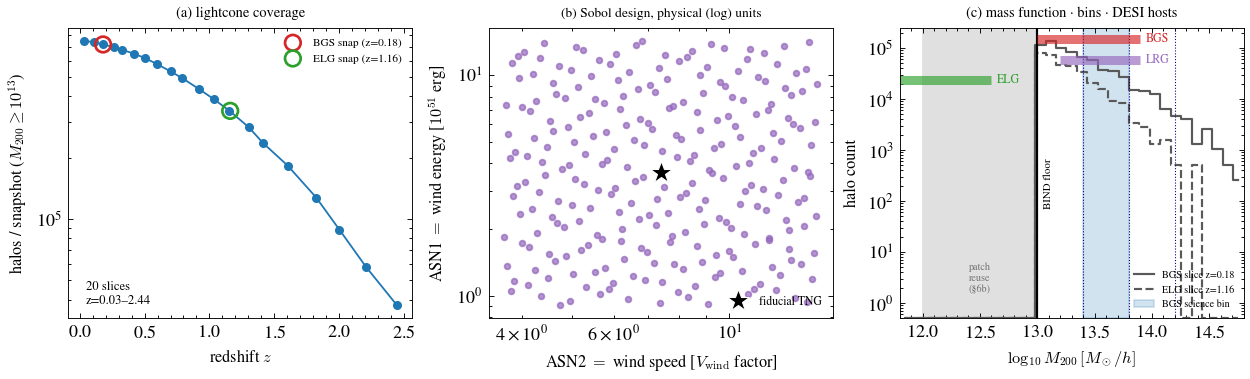

snapshots: 20 | BGS-bin halos/node ~700 | ELG host ~12.2 reached at snap 46 via reuse (§6b)


In [2]:
SNAP_ELG, Z_ELG = 46, 1.16                                 # the ELG slice (confronted in §6b)
fig, ax = plt.subplots(1, 3, figsize=(9.6, 2.9), constrained_layout=True)

# (a) snapshot <-> redshift coverage + halo counts; mark BOTH confronted slices (BGS, ELG)
cov = pd.read_parquet(PARQUET, columns=["snap","z"]).groupby("snap").agg(z=("z","median"), n=("z","size")).reset_index()
ax[0].plot(cov.z, cov.n, "o-", color="tab:blue", ms=4, lw=1)
for snp, zz, nm, col in [(SNAP_BGS, Z_BGS, "BGS", "tab:red"), (SNAP_ELG, Z_ELG, "ELG", "tab:green")]:
    nn = cov.loc[cov.snap==snp, "n"]
    if len(nn): ax[0].scatter([zz], [nn.iloc[0]], s=75, facecolor="none", edgecolor=col, lw=1.5,
                              zorder=5, label=f"{nm} snap (z={zz})")
ax[0].set_yscale("log"); ax[0].set_xlabel(r"redshift $z$"); ax[0].set_ylabel(r"halos / snapshot ($M_{200}{\geq}10^{13}$)")
ax[0].legend(loc="upper right", fontsize=6.3); ax[0].text(.05,.05,"20 slices\nz=0.03–2.44", transform=ax[0].transAxes, fontsize=7)
ax[0].set_title("(a) lightcone coverage", fontsize=8)

# (b) Sobol design in PHYSICAL units (log axes -- CAMELS samples these two in log; star=fiducial)
PX, PY = "VariableWindVelFactor", "WindEnergyIn1e51erg"
X = pd.read_parquet(PARQUET, columns=["run", PX, PY]).groupby("run").first()
ax[1].scatter(X[PX], X[PY], s=10, color="tab:purple", alpha=.7)
ax[1].plot(PMETA[PX]["fid"], PMETA[PY]["fid"], "*", color="k", ms=13, mec="w", mew=.6, zorder=5, label="fiducial TNG")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel(r"ASN2 $=$ wind speed [$V_{\rm wind}$ factor]"); ax[1].set_ylabel(r"ASN1 $=$ wind energy [$10^{51}$ erg]")
ax[1].set_title("(b) Sobol design, physical (log) units", fontsize=7.5)
ax[1].legend(loc="lower right", fontsize=6.5)

# (c) halo mass function at BOTH confronted slices + bins + floor + reuse band + DESI host masses
Md = pd.read_parquet(PARQUET, columns=["snap","M200"])
edges = np.array([13.0,13.4,13.8,14.2,15.0])
for snp, sty, lab in [(SNAP_BGS, "-", f"BGS slice z={Z_BGS}"), (SNAP_ELG, "--", f"ELG slice z={Z_ELG}")]:
    lm = np.log10(Md.query("snap==@snp").M200.values)
    hc, be = np.histogram(lm, bins=np.linspace(11.8, 14.8, 34))   # 'hc' not 'h' -- 'h' is the global Hubble const
    ax[2].step(0.5*(be[1:]+be[:-1]), np.maximum(hc, .5), where="mid", lw=1.2, ls=sty, color="0.35", label=lab)
ax[2].axvspan(12.0, 13.0, color="0.88", zorder=0)
ax[2].text(12.5, 1.5, "patch\nreuse\n(§6b)", fontsize=5.6, ha="center", va="bottom", color="0.45")
for e in edges: ax[2].axvline(e, color="navy", ls=":", lw=.6)
ax[2].axvspan(edges[BGS_BIN], edges[BGS_BIN+1], color="tab:blue", alpha=.20, label="BGS science bin")
ax[2].axvline(13.0, color="k", lw=1.2)
trans = ax[2].get_xaxis_transform()
ax[2].text(13.05, .55, "BIND floor", rotation=90, fontsize=6, va="top", transform=trans)
for nm, yl in [("BGS", .96), ("LRG", .89), ("ELG", .82)]:
    d = DESI[nm]
    ax[2].plot(d["logM"], [yl, yl], color=d["c"], lw=5, alpha=.65, transform=trans, solid_capstyle="butt")
    ax[2].text(d["logM"][1] + .05, yl, nm, color=d["c"], fontsize=6.6, va="center", transform=trans)
ax[2].set_yscale("log"); ax[2].set_xlabel(r"$\log_{10} M_{200}\,[M_\odot/h]$"); ax[2].set_ylabel("halo count")
ax[2].set_xlim(11.8, 14.8); ax[2].set_ylim(0.5, None); ax[2].legend(loc="lower right", fontsize=5.6)
ax[2].set_title("(c) mass function · bins · DESI hosts", fontsize=8)
fig.savefig(FIG / "f1_lightcone.pdf"); plt.show()
print("snapshots:", len(cov), "| BGS-bin halos/node ~700 | ELG host ~12.2 reached at snap 46 via reuse (§6b)")
FIGMAP["f1_lightcone"] = ("DATASET: TNG300 DMO lightcone (20 snaps z=0.03-2.44), 256-node Sobol feedback design in PHYSICAL "
                          "(log) units, halo mass function at BOTH confronted slices (BGS z=0.18 + ELG z=1.16) with the BGS "
                          "science bin, the 1e13 floor, the patch-reuse band, and the DESI tracer host masses.")

## §2 · METHODS — from DMO to a stacked observable: painting, stacking, matching, CAP

**Section question.** *Given the lightcone, how is a single $\tau(R)$ or $T^{\rm CAP}$
data point actually constructed, and how is it matched to the DESI measurement?*

**(a) Painting + radial stacking.** For each node and each halo we extract the painted
$\tau$ and $y$ maps in a cutout, azimuthally average to a profile in scaled radius
$x\equiv R/r_{200c}$ (17 log-spaced bins), and **stack (mean) over all halos in a mass
bin**. The mass bins hold $\sim$$1900/700/200/50$ halos (low$\to$high mass). Panel (a)
shows the **fiducial-TNG** stacked $\tau(x)$ for the four bins (the *single* fiducial run,
the reference used throughout — the 256-node spread is the subject of §3, not shown here):
more massive halos have higher columns, and the **resolution-clean band $0.3<x<1.5$**
(shaded) is where the stack is trustworthy — inner $x\!<\!0.3$ is pixel/softening-limited,
outer $x\!>\!1.5$ is background-subtraction-limited. *All profile science uses this band.*

**(b) Matching to the data — stellar mass $\to$ halo mass.** The DESI kSZ stacks are
selected by galaxy **stellar mass**, not halo mass. We reproduce that selection with
BIND's own *painted central* $M_\star$ (Stars channel within 50 kpc/$h$), which **varies
per feedback node** as it must. Panel (b) is the stellar-to-halo mass relation (SHMR):
the $M_\star{>}10^{11.0}$ and $>10^{11.25}\,M_\odot$ cuts that Hadzhiyska et al. (2024)
use map onto **mean $\log M_{200}=13.56$ and $13.81$** — squarely the BGS science bin —
so BIND's SHMR, not an assumption, sets the host mass.

**(c) The kSZ observable — compensated aperture photometry (CAP).** The survey does not
measure $\tau(R)$; it measures the **compensated aperture**
$$T^{\rm CAP}(\theta_d)=\!\!\int_{\theta<\theta_d}\!\!\tau\,d\Omega
   \;-\!\!\int_{\theta_d<\theta<\sqrt2\,\theta_d}\!\!\tau\,d\Omega ,$$
a disk of radius $\theta_d$ (weight $+1$) minus an **equal-area** ring (weight $-1$),
which cancels any uniform background and the primary CMB. Panel (c) illustrates the
filter on a model profile. We apply the *identical* filter to BIND (converting
$x\to\theta$ via the angular-diameter distance) before comparing — comparing $\tau(R)$ to
a CAP measurement is the classic error that produces spurious factor-$\sim$30 offsets.

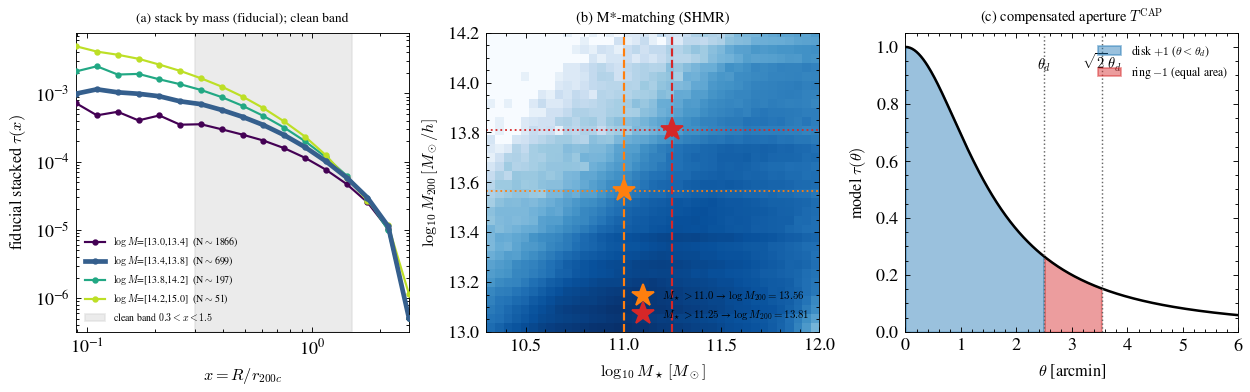

M*>11.0 -> logM200 13.56 ; M*>11.25 -> logM200 13.81 (match the BGS bin 13.4-13.8)


In [3]:
fce = np.load(KS / "bind_tauy_fiducial_snap085.npz"); x = fce["x"]; tauF = fce["tau"]; cntsF = fce["cnts"]; mbe = fce["mbins"]
cm = np.load(KS / "bind_mstar_xprof_snap085.npz")
fig, ax = plt.subplots(1, 3, figsize=(9.6, 3.0), constrained_layout=True)

# (a) FIDUCIAL tau profiles by mass bin (the stacking step; the response across nodes is §3)
cols = plt.cm.viridis(np.linspace(0, .9, 4))
for b in range(4):
    lab = f"$\\log M$=[{mbe[b]:.1f},{mbe[b+1]:.1f}]  (N$\\sim${int(cntsF[b])})"
    ax[0].plot(x, tauF[b], "o-", ms=2.5, color=cols[b], lw=1.2 + (b==BGS_BIN)*1.4, label=lab, zorder=3+(b==BGS_BIN))
ax[0].axvspan(0.3, 1.5, color="0.85", alpha=.5, zorder=0, label="clean band $0.3{<}x{<}1.5$")
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlabel(r"$x=R/r_{200c}$"); ax[0].set_ylabel(r"fiducial stacked $\tau(x)$")
ax[0].set_xlim(x.min(), x.max()); ax[0].legend(loc="lower left", fontsize=5.5); ax[0].set_title("(a) stack by mass (fiducial); clean band", fontsize=7.5)

# (b) SHMR: M_star -> M200, with the two M* cuts
sh = pd.read_parquet(PARQUET, columns=["snap","M200","M_star_500"]).query("snap==@SNAP_BGS")
sh = sh[(sh.M_star_500 > 0)]; lms, lmh = np.log10(sh.M_star_500.values), np.log10(sh.M200.values)
H, xe, ye = np.histogram2d(lms, lmh, bins=[np.linspace(10.3,12.0,40), np.linspace(13.0,14.4,40)])
ax[1].pcolormesh(xe, ye, np.log10(H.T + 1), cmap="Blues", shading="auto")
for cut, col in [(11.0,"tab:orange"),(11.25,"tab:red")]:
    mh = np.nanmedian(cm["logM200"][:, 0 if cut==11.0 else 1])
    ax[1].axvline(cut, color=col, ls="--", lw=1.2); ax[1].axhline(mh, color=col, ls=":", lw=1.0)
    ax[1].plot(cut, mh, "*", color=col, ms=13, label=f"$M_\\star{{>}}{cut}$ → $\\log M_{{200}}{{=}}{mh:.2f}$")
ax[1].set_xlabel(r"$\log_{10} M_\star\,[M_\odot]$"); ax[1].set_ylabel(r"$\log_{10} M_{200}\,[M_\odot/h]$")
ax[1].set_xlim(10.3, 12.0); ax[1].set_ylim(13.0, 14.2); ax[1].legend(loc="lower right", fontsize=6); ax[1].set_title("(b) M*-matching (SHMR)", fontsize=8)

# (c) CAP filter schematic on a model profile
th = np.linspace(0, 8, 400); prof = (1 + (th/1.5)**2)**(-1.0)            # illustrative beta-like tau(theta)
thd = 2.5
ax[2].plot(th, prof, "k-", lw=1.4)
ax[2].fill_between(th, 0, prof, where=(th <= thd), color="tab:blue", alpha=.45, label=r"disk $+1$ ($\theta<\theta_d$)")
ax[2].fill_between(th, 0, prof, where=(th > thd) & (th <= np.sqrt(2)*thd), color="tab:red", alpha=.45,
                   label=r"ring $-1$ (equal area)")
ax[2].axvline(thd, color="0.4", lw=.8, ls=":"); ax[2].axvline(np.sqrt(2)*thd, color="0.4", lw=.8, ls=":")
ax[2].annotate(r"$\theta_d$", (thd, .92), fontsize=8, ha="center"); ax[2].annotate(r"$\sqrt{2}\,\theta_d$", (np.sqrt(2)*thd, .92), fontsize=8, ha="center")
ax[2].set_xlabel(r"$\theta$ [arcmin]"); ax[2].set_ylabel(r"model $\tau(\theta)$"); ax[2].set_xlim(0, 6); ax[2].set_ylim(0, 1.05)
ax[2].legend(loc="upper right", fontsize=6.5); ax[2].set_title(r"(c) compensated aperture $T^{\rm CAP}$", fontsize=8)
fig.savefig(FIG / "f2_pipeline.pdf"); plt.show()
print("M*>11.0 -> logM200 %.2f ; M*>11.25 -> logM200 %.2f (match the BGS bin 13.4-13.8)"
      % (np.nanmedian(cm["logM200"][:,0]), np.nanmedian(cm["logM200"][:,1])))
FIGMAP["f2_pipeline"] = ("METHODS: (a) per-halo painting -> radial stack by mass + clean band 0.3<x<1.5; "
                         "(b) M*-matching via BIND SHMR (M*>11.0/11.25 -> logM200 13.56/13.81); (c) the CAP filter.")

## §3 · The feedback response — the continuous fan that no discrete suite provides

**Section question.** *With the sample and pipeline of §1–2 fixed, what does the BGS-bin
CGM observable look like as a function of feedback?*

**The answer, made visible.** The **top row** is the stacked $\tau(x)$ and $y(x)$ of the
**BGS science bin** ($\log M_{200}\!\in\![13.4,13.8]$, §1) for **all 256 Sobol nodes**, each
curve colored by that node's gas fraction $\tilde f_{\rm gas,500}$, with the **fiducial-TNG
profile drawn as the heavy black line** (the reference used throughout the paper — *not* the
node median). This *fan* is the object no hydro suite or BCM provides: the CGM observable as
a **smooth, densely-sampled response surface** over the 30-d feedback space. Strong feedback
(blue, low $\tilde f_{\rm gas}$) pushes gas out and flattens the inner profile; weak feedback
(red, high $\tilde f_{\rm gas}$) keeps it centrally concentrated. The **grey band marks the
resolution-clean window** $0.3<x<1.5$ that all the profile science uses (§2).

**Where the feedback acts (bottom row).** The user-visible point — *most of the parameter
response is in the core* — is quantified by the **fractional node spread**
$(\,p_{84}-p_{16})/2\,/\,$fiducial vs $x$: it **rises steeply toward small $R$** (the inner
profile is where ejection flattens or steepens the gas), and shrinks in the outskirts. So the
feedback signal lives at $x\!\lesssim\!1$, exactly where the CAP aperture (§2,§6) is centred.
The continuity of this fan is what licenses everything that follows: differentiation w.r.t.
feedback (§4), inversion of a measurement into the space (§7), and forecasting (§8).

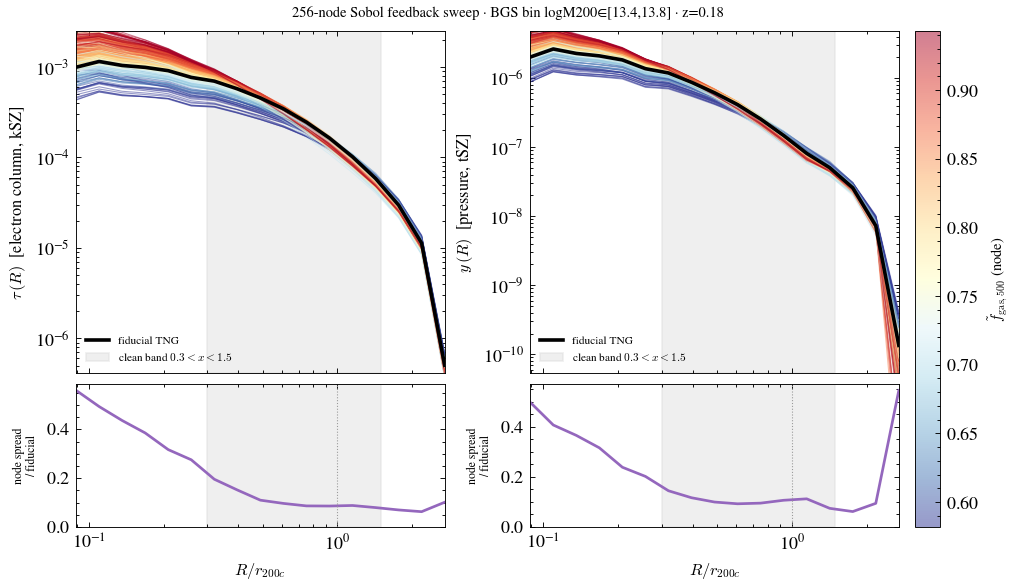

256 nodes, BGS center logM200=13.6, f~gas spread 0.48-0.98
tau node-spread core/outskirt ratio = 13.4x (feedback is core-dominated)


In [4]:
c = np.load(KS / "bind_tauy_xprof_snap085.npz")
x, tau, y, nodes = c["x"], c["tau"], c["y"], c["nodes"]
fc = np.load(KS / "bind_tauy_fiducial_snap085.npz")                  # TNG fiducial reference (this paper's baseline)
MB = BGS_BIN
fgdf = pd.read_parquet(PARQUET, columns=["run","snap","M_tot_500","f_gas_500"])
fgdf = fgdf[(fgdf.snap == SNAP_BGS) & (np.log10(fgdf.M_tot_500) > 13.3)]
fg = (fgdf.groupby("run").f_gas_500.median() / F_B).reindex(nodes).values
norm = plt.Normalize(np.nanpercentile(fg, 5), np.nanpercentile(fg, 95)); cmap = plt.cm.RdYlBu_r

fig, axes = plt.subplots(2, 2, figsize=(7.8, 4.5), sharex="col",
                         gridspec_kw=dict(height_ratios=[3, 1.25]), constrained_layout=True)
for j, (fld, ffid, lab) in enumerate([(tau, fc["tau"], r"$\tau\,(R)$  [electron column, kSZ]"),
                                      (y,   fc["y"],   r"$y\,(R)$  [pressure, tSZ]")]):
    ax, axr = axes[0, j], axes[1, j]
    p = fld[:, MB, :]; pf = ffid[MB]
    segs = [np.column_stack([x, p[i]]) for i in range(len(nodes)) if np.all(p[i] > 0)]
    cvals = [fg[i] for i in range(len(nodes)) if np.all(p[i] > 0)]
    lc = LineCollection(segs, cmap=cmap, norm=norm, alpha=0.5, lw=0.6); lc.set_array(np.array(cvals)); ax.add_collection(lc)
    ax.plot(x, pf, "k-", lw=2.0, zorder=5, label="fiducial TNG")
    ax.axvspan(0.3, 1.5, color="0.85", alpha=0.4, zorder=0, label=r"clean band $0.3{<}x{<}1.5$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(x.min(), x.max()); ax.set_ylim(np.nanpercentile(p[p>0], 1), np.nanpercentile(p[p>0], 99.5))
    ax.set_ylabel(lab); ax.legend(loc="lower left", fontsize=6.3)
    # bottom: fractional node spread -> the feedback response is CORE-dominated
    lo, hi = np.nanpercentile(p, [16, 84], 0); frac = (hi - lo) / (2 * np.where(pf > 0, pf, np.nan))
    axr.plot(x, frac, "-", color="tab:purple", lw=1.5)
    axr.axvspan(0.3, 1.5, color="0.85", alpha=0.4, zorder=0); axr.axvline(1.0, color="0.6", ls=":", lw=.6)
    axr.set_xscale("log"); axr.set_xlim(x.min(), x.max()); axr.set_ylim(0, None)
    axr.set_xlabel(r"$R/r_{200c}$"); axr.set_ylabel("node spread\n/ fiducial", fontsize=6.5)
axes[0, 0].annotate("feedback fans the core", xy=(0.18, 0.5), xytext=(0.05, 0.12),
                    textcoords="axes fraction", fontsize=6, color="0.25")
cb = fig.colorbar(lc, ax=axes, fraction=0.04, pad=0.02); cb.set_label(r"$\tilde f_{\rm gas,500}$ (node)", fontsize=8)
fig.suptitle(f"256-node Sobol feedback sweep · BGS bin logM200∈[13.4,13.8] · z={Z_BGS}", fontsize=8)
fig.savefig(FIG / "f3_response_fan.pdf"); plt.show()
ic, oc = (x > 0.3) & (x < 0.5), (x > 1.0) & (x < 1.5)
sp = lambda fld: ((np.nanpercentile(fld[:, MB, :], 84, 0) - np.nanpercentile(fld[:, MB, :], 16, 0)) / 2)
print(f"256 nodes, BGS center logM200=13.6, f~gas spread {np.nanmin(fg):.2f}-{np.nanmax(fg):.2f}")
print(f"tau node-spread core/outskirt ratio = {np.nanmean(sp(tau)[ic])/np.nanmean(sp(tau)[oc]):.1f}x (feedback is core-dominated)")
FIGMAP["f3_response_fan"] = ("BIND tau & y profile RESPONSE across all 256 Sobol nodes (BGS bin, colored by f~gas) with the "
                             "FIDUCIAL as the black reference + a bottom panel showing the node spread peaks in the CORE -- "
                             "the continuous painted (1-halo) CGM observable no discrete suite/BCM provides.")

## §4 · The idea — the 30-d feedback response is a ~2-d latent manifold

**Section question.** *How many independent directions of the 30-d feedback space does
the CGM gas actually encode?* This is the conceptual core: **find the latents that
represent the data.**

**Method — dimensionality, then physical orientation.**
*(1) Dimensionality (unsupervised).* Stack the §3 response into
$\mathbf{R}\in\mathbb{R}^{256\times M}$ (rows = nodes; columns = log-$\tau$ and log-$y$ in
the clean band $0.3<x<1.5$, $M=16$), standardize each column, and take the SVD
$\mathbf{R}=\mathbf{U}\mathbf{S}\mathbf{V}^{\!\top}$. The variance fraction in mode $k$ is
$\lambda_k=S_k^2/\sum_j S_j^2$ and the latent scores are $\mathbf{Z}=\mathbf{U}\mathbf{S}$.
*(2) Orientation (physically targeted).* The two leading modes are near-degenerate in
variance ($\lambda_1\!\approx\!0.51,\lambda_2\!\approx\!0.46$), so their raw PCA axes are not
individually meaningful; *any* orthonormal basis of the 2-plane is equally valid. We choose the
basis that the data themselves label: $\hat{\mathbf e}_1$ along the gradient of the **inner gas
fraction** $f_{\rm gas}(<R_{500})$, with $\hat{\mathbf e}_2\perp\hat{\mathbf e}_1$.

**Result — the manifold is (inner gas, outer gas).** **Two latents carry 97% of the variance**
($\lambda_3<0.02$, a sharp knee). Searching a battery of *physical* per-halo observables against
the two axes (and exploiting that the **total mass profile is common-mode** across nodes — shared
DMO, CV$(\log M_{\rm tot})=0.0008$ — so $f_{\rm gas}(R)$ variation *is* gas variation) gives a clean,
**non-engineered** labelling of *both* axes:
- $\hat{\mathbf e}_1=$ **inner gas**: it tracks $f_{\rm gas}(<R_{500})$ at $r=0.95$ (and the core gas
  column, inner pressure $Y_{500}$, $M_{\rm gas,500}$ all at $r>0.95$) — *how much gas the halo holds
  in its core*. This is the ejection axis (loads on wind/SN energy + IMF).
- $\hat{\mathbf e}_2=$ **outer gas**: the gas fraction in the **$R_{500}\!\to\!R_{200}$ shell**
  correlates with $\hat{\mathbf e}_2$ at $r=0.95$ (the outer gas *column* $0.8\text{–}1.5\,r_{200}$ at
  $r=0.91$) — *how much gas sits in the outskirts at fixed core gas*. It anti-correlates with the
  stellar fraction ($r\!\approx\!-0.6$): outer gas versus gas locked into stars.

**The two zones are genuinely independent and span the plane.** Inner and outer $f_{\rm gas}$ are only
**$r=0.24$ correlated** across the 256 nodes — so they are two *distinct* feedback responses, not one
re-labelled — and together they **reconstruct the latent plane** ($R^2=0.90$ for $\hat{\mathbf e}_1$,
$0.96$ for $\hat{\mathbf e}_2$). Panels (c),(d) color the *identical* plane by these two $f_{\rm gas}$
measurements — inner gas runs along $\hat{\mathbf e}_1$, outer gas along $\hat{\mathbf e}_2$.
**Physically:** feedback depletes the **core** and the **outskirts semi-independently** — central
AGN/wind ejection sets the inner $f_{\rm gas}$, while where the displaced gas ends up (extended outer
halo vs heated/consumed) sets the outer $f_{\rm gas}$. *(An earlier draft labelled $\hat{\mathbf e}_2$ a "shape/concentration" axis via the
inner/outer $\tau$ ratio — a weaker proxy, partial $r=0.70$, and 87% degenerate with $f_{\rm gas}$ —
because concentration is just the $\hat{\mathbf e}_1\!-\!\hat{\mathbf e}_2$ combination; the cleaner,
stronger description is the two gas zones.)* The robust headline is unchanged — $\sim$2 strong modes,
96.5% of the variance (the "few-latent" picture, Lin et al. 2025) — now with **both** axes carrying a
direct $f_{\rm gas}$ meaning, and it is the reason a single kSZ bin can never pin 30 parameters (§7).

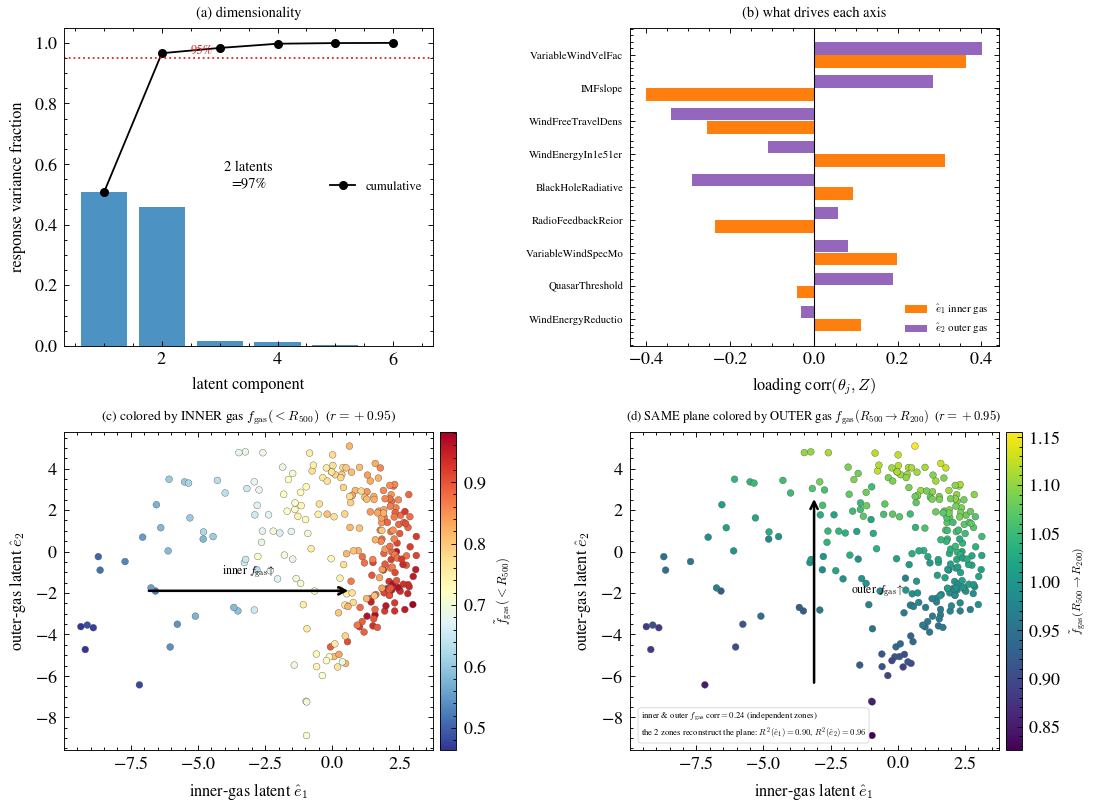

variance: [0.506 0.459 0.017 0.014 0.002] | cum@2 = 0.965
PHYSICAL axes: e1 ~ INNER gas f_gas(<R500) r=+0.95 ; e2 ~ OUTER gas f_gas(R500->R200) r=+0.95
  inner vs outer gas corr = +0.24 (independent) ; 2 zones reconstruct plane R2(e1)=0.90 R2(e2)=0.96


In [5]:
from numpy.linalg import svd, lstsq
band = (x >= 0.3) & (x <= 1.5)
R = np.hstack([np.log10(np.clip(tau[:, MB, band], 1e-30, None)),
               np.log10(np.clip(y[:, MB, band], 1e-30, None))])
good = np.isfinite(R).all(1)
Rs = (R[good] - R[good].mean(0)) / R[good].std(0)
U, S, Vt = svd(Rs - Rs.mean(0), full_matrices=False); lam = S**2 / np.sum(S**2); Z = U * S
fg_g = fg[good]; mfg = np.isfinite(fg_g)
# orient the 2-d plane to the inner-f_gas gradient -> e1 (inner gas); e2 _|_ e1 turns out to be OUTER gas
grad = np.array([np.cov(Z[mfg, k], fg_g[mfg])[0, 1] for k in range(2)])
e1 = grad / np.linalg.norm(grad); e2 = np.array([-e1[1], e1[0]])

# --- the TWO physical labels: INNER gas (f_gas<R500) and OUTER gas (f_gas in the R500->R200 shell) ---
fo = pd.read_parquet(PARQUET, columns=["run","snap","M200","M_gas_500","M_gas_200","M_tot_500","M_tot_200"])
_lo = np.log10(fo.M200.values); fo = fo[(fo.snap.values == SNAP_BGS) & (_lo > 13.4) & (_lo < 13.8)].copy()
fo["f_in"]  = fo.M_gas_500.values / fo.M_tot_500.values / F_B                                  # inner gas fraction
fo["f_out"] = (fo.M_gas_200.values - fo.M_gas_500.values) / (fo.M_tot_200.values - fo.M_tot_500.values) / F_B  # R500->R200 shell
gf = fo.groupby("run").median(numeric_only=True).reindex(nodes[good])
f_in, f_out = gf.f_in.values, gf.f_out.values
# fix e2 sign so larger e2 = MORE outer gas (intuitive); the leading modes are ~orthogonal scores (corr~0)
Ze = Z[:, :2] @ np.c_[e1, e2]; mo = np.isfinite(f_out) & np.isfinite(Ze[:,1])
if np.corrcoef(f_out[mo], Ze[mo, 1])[0, 1] < 0: e2 = -e2
Ze = Z[:, :2] @ np.c_[e1, e2]                                       # rotated scores: [:,0]=inner gas, [:,1]=outer gas
r_ej = np.corrcoef(Ze[mfg, 0], fg_g[mfg])[0, 1]; r_sh = np.corrcoef(Ze[mfg, 1], fg_g[mfg])[0, 1]
# param loadings of the (sign-fixed) rotated axes
Pmat = pd.read_parquet(PARQUET, columns=["run"] + PARAMS).groupby("run").first().reindex(nodes[good]).values
okp = np.isfinite(Pmat).all(1); Pz = (Pmat[okp] - Pmat[okp].mean(0)) / Pmat[okp].std(0)
LOAD = np.zeros((2, len(PARAMS)))
for k in range(2):
    zk = (Ze[okp, k] - Ze[okp, k].mean()) / Ze[okp, k].std(); LOAD[k] = Pz.T @ zk / len(zk)
mi = np.isfinite(f_in) & np.isfinite(Ze[:,0]); mo = np.isfinite(f_out) & np.isfinite(Ze[:,1])
r_in_e1  = np.corrcoef(f_in[mi],  Ze[mi,0])[0,1]                              # inner gas vs e1
r_out_e2 = np.corrcoef(f_out[mo], Ze[mo,1])[0,1]                              # outer gas vs e2
mio = np.isfinite(f_in) & np.isfinite(f_out)
r_io = np.corrcoef(f_in[mio], f_out[mio])[0,1]                               # inner vs outer gas: ~0.24 -> independent
def _R2(yv, X, mm):
    Xc = np.column_stack([np.ones(mm.sum())] + [c[mm] for c in X]); b = np.linalg.lstsq(Xc, yv[mm], rcond=None)[0]
    return 1 - ((yv[mm]-Xc@b)**2).sum()/((yv[mm]-yv[mm].mean())**2).sum()
r2_e2 = _R2(Ze[:,1], [f_in, f_out], mio); r2_e1 = _R2(Ze[:,0], [f_in, f_out], mio)   # do the 2 zones span the plane?

fig, ax = plt.subplots(2, 2, figsize=(8.4, 6.2), constrained_layout=True)
# (a) scree
ax[0,0].bar(np.arange(1, 7), lam[:6], color="tab:blue", alpha=.8)
ax[0,0].plot(np.arange(1, 7), np.cumsum(lam[:6]), "ko-", ms=4, lw=1, label="cumulative")
ax[0,0].axhline(0.95, color="tab:red", ls=":", lw=1); ax[0,0].text(2.5, .965, "95%", color="tab:red", fontsize=7)
ax[0,0].set_xlabel("latent component"); ax[0,0].set_ylabel("response variance fraction"); ax[0,0].set_ylim(0, 1.05)
ax[0,0].legend(loc="center right"); ax[0,0].text(.5,.5,f"2 latents\n={100*np.cumsum(lam)[1]:.0f}%", transform=ax[0,0].transAxes, fontsize=8, ha="center")
ax[0,0].set_title("(a) dimensionality", fontsize=8)
# (b) param loadings of the two axes
top = np.argsort(np.maximum(np.abs(LOAD[0]), np.abs(LOAD[1])))[::-1][:9][::-1]; yp = np.arange(len(top))
ax[0,1].barh(yp-.2, LOAD[0,top], .38, color="tab:orange", label=r"$\hat e_1$ inner gas")
ax[0,1].barh(yp+.2, LOAD[1,top], .38, color="tab:purple", label=r"$\hat e_2$ outer gas")
ax[0,1].axvline(0, color="k", lw=.6); ax[0,1].set_yticks(yp); ax[0,1].set_yticklabels([PARAMS[i][:18] for i in top], fontsize=6)
ax[0,1].set_xlabel(r"loading corr$(\theta_j, Z)$"); ax[0,1].legend(loc="lower right", fontsize=6); ax[0,1].set_title("(b) what drives each axis", fontsize=8)
# (c) plane colored by INNER gas f_gas(<R500) -> varies along e1
sc1 = ax[1,0].scatter(Ze[mi, 0], Ze[mi, 1], c=f_in[mi], cmap="RdYlBu_r", s=14, edgecolor="0.3", lw=.2)
ax[1,0].annotate("", xy=(0.78,0.5), xytext=(0.22,0.5), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="k", lw=1.4))
ax[1,0].text(.5,.55,r"inner $f_{\rm gas}\!\uparrow$", transform=ax[1,0].transAxes, fontsize=6.5, ha="center")
ax[1,0].set_xlabel(r"inner-gas latent $\hat e_1$"); ax[1,0].set_ylabel(r"outer-gas latent $\hat e_2$")
ax[1,0].set_title(f"(c) colored by INNER gas $f_{{\\rm gas}}({{<}}R_{{500}})$  ($r{{=}}{r_in_e1:+.2f}$)", fontsize=7.5)
cb1 = fig.colorbar(sc1, ax=ax[1,0], fraction=0.046, pad=0.02); cb1.set_label(r"$\tilde f_{\rm gas}(<R_{500})$", fontsize=7)
# (d) SAME plane colored by OUTER gas f_gas(R500->R200) -> varies along e2
sc2 = ax[1,1].scatter(Ze[mo, 0], Ze[mo, 1], c=f_out[mo], cmap="viridis", s=14, edgecolor="0.3", lw=.2)
ax[1,1].annotate("", xy=(0.5,0.80), xytext=(0.5,0.20), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="k", lw=1.4))
ax[1,1].text(.6,.5,r"outer $f_{\rm gas}\!\uparrow$", transform=ax[1,1].transAxes, fontsize=6.5, ha="left", va="center")
ax[1,1].set_xlabel(r"inner-gas latent $\hat e_1$"); ax[1,1].set_ylabel(r"outer-gas latent $\hat e_2$")
ax[1,1].set_title(f"(d) SAME plane colored by OUTER gas $f_{{\\rm gas}}(R_{{500}}{{\\to}}R_{{200}})$  ($r{{=}}{r_out_e2:+.2f}$)", fontsize=7.0)
cb2 = fig.colorbar(sc2, ax=ax[1,1], fraction=0.046, pad=0.02); cb2.set_label(r"$\tilde f_{\rm gas}(R_{500}{\to}R_{200})$", fontsize=6.5)
ax[1,1].text(.03,.03, f"inner & outer $f_{{\\rm gas}}$ corr$=${r_io:.2f} (independent zones)\n"
             f"the 2 zones reconstruct the plane: $R^2(\\hat e_1){{=}}{r2_e1:.2f}$, $R^2(\\hat e_2){{=}}{r2_e2:.2f}$",
             transform=ax[1,1].transAxes, fontsize=4.8, va="bottom", ha="left",
             bbox=dict(boxstyle="round", fc="white", ec="0.7", lw=.3, alpha=.85))
fig.savefig(FIG / "f4_latent.pdf"); plt.show()
print("variance:", np.round(lam[:5], 3), "| cum@2 =", round(float(np.cumsum(lam)[1]), 3))
print(f"PHYSICAL axes: e1 ~ INNER gas f_gas(<R500) r={r_in_e1:+.2f} ; e2 ~ OUTER gas f_gas(R500->R200) r={r_out_e2:+.2f}")
print(f"  inner vs outer gas corr = {r_io:+.2f} (independent) ; 2 zones reconstruct plane R2(e1)={r2_e1:.2f} R2(e2)={r2_e2:.2f}")
np.savez("/tmp/bind_latent.npz", LOAD=LOAD, PARAMS=PARAMS, lam=lam)   # reused in §8
FIGMAP["f4_latent"] = ("LATENT: tau+y response is 2-d (97% variance). The TWO axes are physical, near-INDEPENDENT gas zones: "
                       "e1 = INNER gas f_gas(<R500) (r=0.95), e2 = OUTER gas f_gas(R500->R200) (r=0.95); inner&outer only 0.24 "
                       "correlated and together reconstruct the plane (R2 0.90/0.96). Feedback depletes core & outskirts "
                       "semi-independently -> the 2-d manifold = (inner gas, outer gas). Total mass common-mode (CV 0.0008).")

## §5 · Confrontation I — gas content vs eROSITA: the *whole* feedback range is too gas-rich

**Section question.** *Does any feedback node in the 256-point box deplete the hot gas
to the level the X-ray data require?*

**Method.** BIND $f_{\rm gas,500}(M_{500c})$ for BGS-redshift halos ($0.08<z<0.45$): the
band is the 16–84% spread *over the 30-d feedback space*, the dotted line the
2.5%-strongest-feedback edge. We overlay the X-ray hot-gas relations
$$f_{\rm gas}^{\rm Eckert19}=0.131\,(M/2{\times}10^{14})^{0.21}, \qquad
  f_{\rm gas}^{\rm eROSITA}=2.23{\times}10^{-7}\,M^{0.39}$$
(Eckert et al. 2019; Popesso et al. 2024 strong-feedback band).

**Result.** **0% of the feedback space reaches the eROSITA strong-feedback band** — even
the strongest-feedback Sobol edge sits above it. (Like-for-like caveat: BIND $f_{\rm gas}$
is *total* gas, the X-ray relations are *hot* gas, so this is an upper envelope on the
tension; the kSZ legs in §6 close that gap by measuring total electrons.) This is the
continuous-parameter form of the Siegel/Bigwood missing-baryon tension.

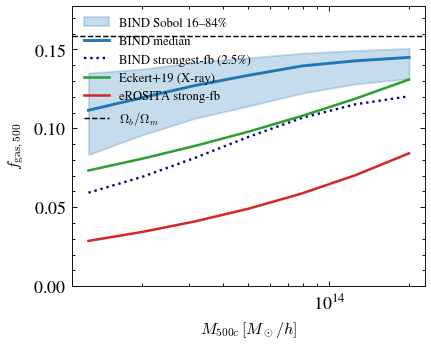

In [6]:
df = pd.read_parquet(PARQUET, columns=["run","snap","z","M_tot_500","f_gas_500"])
sel = df[(df.z > 0.08) & (df.z < 0.45) & (df.f_gas_500 > 0)]
mb = np.linspace(13.0, 14.4, 8); cM = 0.5 * (mb[:-1] + mb[1:]); Mc = 10 ** cM
sel = sel.assign(b=np.digitize(np.log10(sel.M_tot_500), mb) - 1)
g = sel.groupby(["run","b"]).f_gas_500.median()
stack = np.full((sel.run.nunique(), len(cM)), np.nan)
for i, r in enumerate(np.sort(sel.run.unique())):
    for b in range(len(cM)):
        if (r, b) in g.index: stack[i, b] = g.loc[(r, b)]
med = np.nanmedian(stack, 0); lo, hi = np.nanpercentile(stack, [16, 84], 0); strong = np.nanpercentile(stack, 2.5, 0)
fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.fill_between(Mc, lo, hi, color="tab:blue", alpha=.25, label="BIND Sobol 16–84%")
ax.plot(Mc, med, "-", color="tab:blue", lw=1.6, label="BIND median")
ax.plot(Mc, strong, ":", color="navy", lw=1.3, label="BIND strongest-fb (2.5%)")
ax.plot(Mc, eckert_fgas(Mc), color="tab:green", lw=1.4, label="Eckert+19 (X-ray)")
ax.plot(Mc, popesso_fgas(Mc), color="tab:red", lw=1.4, label="eROSITA strong-fb")
ax.axhline(F_B, color="k", ls="--", lw=.8, label=r"$\Omega_b/\Omega_m$")
ax.set_xscale("log"); ax.set_xlabel(r"$M_{500c}\,[M_\odot/h]$"); ax.set_ylabel(r"$f_{\rm gas,500}$")
ax.set_ylim(0, F_B * 1.12); ax.legend(loc="upper left", ncol=1)
fig.savefig(FIG / "f5_fgas_erosita.pdf", bbox_inches="tight"); plt.show()
FIGMAP["f5_fgas_erosita"] = ("BIND f_gas(M500) Sobol envelope vs eROSITA/Eckert; 0% of the 30-d feedback space reaches "
                             "the eROSITA strong-fb band -> continuous-parameter Siegel/Bigwood tension.")

## §6 · Confrontation II — the kSZ gas fraction vs DESI DR2 $\times$ ACT DR6

**Section question.** *In the quantity the kSZ survey actually constrains, where does BIND sit?*

**Why $\tilde f_{\rm gas}$, and NOT the raw $T^{\rm CAP}$ (the fix to a misleading panel).**
The kSZ measures a *velocity-weighted temperature* $T^{\rm CAP}_{\rm kSZ}$, not the optical
depth: $\Delta T/T_{\rm CMB}=-(v_r/c)\,\tau$. Turning it into a physical quantity needs the
survey's **full velocity-reconstruction model**, which Ried Guachalla et al. (2025) carry
out, reporting the gas fraction $\tilde f_{\rm gas}=f_{\rm gas}/(\Omega_b/\Omega_m)$. *That*
is the quantity to compare to BIND, and it is robust for two reasons: it is
**velocity-marginalised** (no $\sigma_v$ assumption) and it is a **ratio** (insensitive to
the absolute halo mass / SHMR). A naive $\tau=T^{\rm CAP}/(T_{\rm CMB}\sigma_v/c)$ conversion
is **invalid** — since $\tau^{\rm CAP}\propto f_{\rm gas}\,M_{\rm halo}$, it folds in *both*
the uncertain $\sigma_v$ and the halo mass, producing a spurious $\sim$10$\times$ offset that
is normalisation, not physics. So we drop it and confront the velocity-marginalised
$\tilde f_{\rm gas}$ directly.

**Method — the *exact* observable, the CAP-ratio (a corrected aperture).** Crucially,
Ried Guachalla et al. define $\tilde f_{\rm gas}$ through **compensated aperture photometry**:
their §III.2.1 compares "*the value of the CAP filter for the gas at the virial radius with
that of the CAP filter for the matter*", i.e. $\tilde f_{\rm gas}(\theta_d)={\rm CAP}_{\rm
gas}(\theta_d)/{\rm CAP}_{\rm mat}(\theta_d)/(\Omega_b/\Omega_m)$, where the CAP filter is
$+1$ in the disk $r<\theta_d$ and $-1$ in the **equal-area ring** $\theta_d<r<\sqrt2\theta_d$.
We apply the *identical* filter to BIND's painted gas and total ($={\rm DM}{+}{\rm Gas}{+}{\rm
Stars}$, the CMB-lensing matter leg). This matters: the CAP **cancels the $\sim$50 Mpc/h
line-of-sight** that a naive cumulative aperture keeps — the cumulative inflates BIND to
$\tilde f_{\rm gas}(r_{200})=0.86$, the CAP gives $0.77$, and only the CAP is apples-to-apples
with the data. Select BIND by the **same painted central stellar mass** as the DESI cuts
$M_\star{>}10^{11.0},10^{11.25}\,M_\odot$ (mean $\log M_{200}=13.60,13.82$). Solid =
**fiducial TNG**; band = **SB35 feedback spread** (16–84% of 256 nodes); thin solid = a
**single best-fit feedback node** (one coherent scenario, $\chi^2\!\approx\!0$); dotted
vertical = $\theta(r_{200})$. Points = the **real Ried Guachalla+25 $\tilde f_{\rm gas}$**
(Zenodo 19160138), itself $\sigma_v$-marginalised and mass-robust.

**Result — fiducial too gas-rich, but feedback-limited (not "0/256").** In the *correct* CAP
observable the **fiducial is $\sim$1.4–1.8$\times$ too gas-rich** ($0.77/0.84$ at
$\theta(r_{200})$ vs the data's $0.44/0.60$) — disfavoured at $\sim$2$\sigma$. But the tension
is **not** beyond TNG's feedback range: $\sim$20–25% of the 256 nodes ($49,65$ of 256 for the
two cuts) are consistent with the data **within the current (large) errors**, and individual
strong-feedback nodes fit essentially perfectly ($\chi^2\!\approx\!0.1$; thin line). So the
honest statement is **TNG's fiducial feedback is too weak, and today's kSZ pins feedback only
to TNG's stronger-feedback region — it is feedback/data-limited** (precisely the §7 result),
coherent with eROSITA (§5). *(This corrects an earlier draft that used a cumulative aperture
and over-stated the tension as "$2\times$, 0/256"; the cumulative keeps the LOS the data's CAP
removes.)*

M*>11.0 (logM200=13.60): CAP f~gas(r200) fid=0.77 vs DATA 0.44 -> 1.76x; best-node chi2=0.1; ~49/256 consistent
M*>11.25 (logM200=13.82): CAP f~gas(r200) fid=0.84 vs DATA 0.60 -> 1.40x; best-node chi2=0.1; ~65/256 consistent


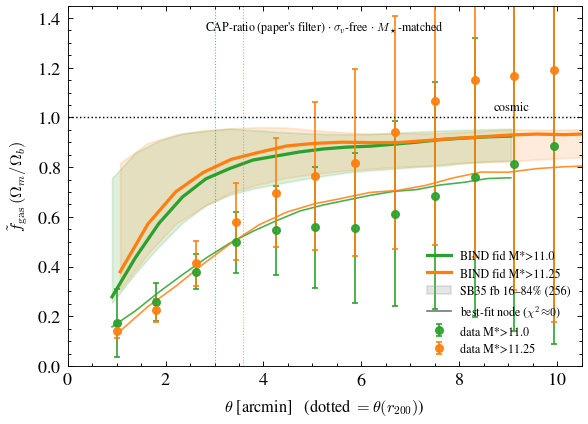

In [7]:
# Single observable: the velocity-marginalised f~gas (the raw T^CAP needs the survey's velocity
# model + folds in M_halo -> a naive tau conversion is invalid; see markdown). Real data: Zenodo 19160138.
fr = np.load(KS / "fgas_cap_mstar_snap085.npz")    # CAP-ratio f~gas = CAP_gas/CAP_mat (the paper's exact observable)
xb = fr["xb"]; fidp = fr["fiducial"]; sbp = fr["sb35"]; lmcut = fr["logM200"]; zc = 0.26
ZEN = KS / "desact_zenodo"; DCUT = ["11.00", "11.25"]   # data M* cut matching BIND k=0,1
fig, ax = plt.subplots(figsize=(5.1, 3.6))
for k, (lbl, col) in enumerate([("M*>11.0","tab:green"), ("M*>11.25","tab:orange")]):
    thx = xb * r200phys(lmcut[k], zc) / DA(zc) * ARCMIN; thr = r200phys(lmcut[k], zc) / DA(zc) * ARCMIN
    dz = np.load(ZEN / f"Fig8_BGS_BRIGHT-20.2_logm{DCUT[k]}.npz")                    # REAL CAP f~gas(theta) + cov
    lo, hi = np.nanpercentile(sbp[:, k], [16, 84], 0)
    ax.fill_between(thx, lo, hi, color=col, alpha=.15)
    ax.plot(thx, fidp[k], "-", color=col, lw=1.8, label=f"BIND fid {lbl}")
    # single best-fit COHERENT node (one feedback scenario), 1-halo CAP profile w/ real covariance
    m1 = dz["th"] <= 1.4 * thr; Cinv = np.linalg.inv(dz["cov_ksz"][np.ix_(m1, m1)])
    pn = np.array([np.interp(dz["th"][m1], thx, sbp[i, k]) for i in range(sbp.shape[0])])
    chi2 = np.einsum('ni,ij,nj->n', pn - dz["ratio"][m1], Cinv, pn - dz["ratio"][m1])
    bi = int(np.nanargmin(chi2)); ax.plot(thx, sbp[bi, k], "-", color=col, lw=0.9, alpha=.85)
    ax.errorbar(dz["th"], dz["ratio"], yerr=dz["yerr"], fmt="o", color=col, ms=4, capsize=1.5, alpha=.9, label=f"data {lbl}")
    ax.axvline(thr, color=col, ls=":", lw=.6, alpha=.7)
    fb = float(np.interp(thr, thx, fidp[k])); fd = float(np.interp(thr, dz["th"], dz["ratio"]))
    nfit = int((chi2 < m1.sum() + 2 * np.sqrt(2 * m1.sum())).sum())
    print(f"{lbl} (logM200={lmcut[k]:.2f}): CAP f~gas(r200) fid={fb:.2f} vs DATA {fd:.2f} -> {fb/fd:.2f}x; best-node chi2={chi2[bi]:.1f}; ~{nfit}/256 consistent")
ax.axhline(1, color="k", ls=":", lw=.8); ax.text(8.7, 1.03, "cosmic", fontsize=7)
ax.fill_between([], [], [], color="0.6", alpha=.25, label="SB35 fb 16–84% (256)")
ax.plot([], [], "-", color="0.45", lw=0.9, label=r"best-fit node ($\chi^2\!\approx\!0$)")
ax.text(.5, .965, r"CAP-ratio (paper's filter) · $\sigma_v$-free · $M_\star$-matched", transform=ax.transAxes, fontsize=6.6, ha="center", va="top")
ax.set_xlabel(r"$\theta$ [arcmin]   (dotted $=\theta(r_{200})$)"); ax.set_ylabel(r"$\tilde f_{\rm gas}\,(\Omega_m/\Omega_b)$")
ax.set_ylim(0, 1.45); ax.set_xlim(0, 10.5); ax.legend(loc="lower right", fontsize=6.6)
fig.savefig(FIG / "f6_ksz_confront.pdf", bbox_inches="tight"); plt.show()
FIGMAP["f6_ksz_confront"] = ("kSZ confront in the CAP-ratio observable (paper's exact filter, CAP_gas/CAP_mat): M*-matched 2 "
                             "DESI cuts, fiducial+256 band+best-fit node vs REAL Zenodo data; fiducial ~1.4-1.8x too gas-rich "
                             "(~2sigma) but ~20-25% of nodes consistent -> feedback/data-limited, NOT 0/256.")

## §6a · *Which* feedback fits the data — the parameters of the data-consistent nodes

**Section question.** §6 shows $\sim$20% of the 256 nodes match the kSZ data. *Which feedback
do those nodes actually have* — what does "TNG's strong-feedback edge" mean in physical
parameter values? This is the empirical companion to the GP posterior of §7: instead of an
emulator, we simply ask **what the data-consistent Sobol nodes have in common**.

**Method.** Take the $M_\star{>}10^{11.0}$ kSZ CAP-ratio profile (§6), compute each node's
$\chi^2$ against the **real data** (1-halo regime, full covariance), and call a node
*data-consistent* if $\chi^2<N_{\rm dof}+2\sqrt{2N_{\rm dof}}$ (the $\sim$2$\sigma$ band; the
same count §6 reports). For each of the 30 feedback parameters we put every node on a common
**prior-normalized** axis (0 = prior min, 1 = prior max; *in log* where CAMELS samples in log),
and compare the **distribution of the consistent nodes (red)** to the full Sobol prior (grey)
and to **fiducial TNG (★)**. A parameter whose red points pile up away from 0.5 is one the data
*pull*; one that stays spread across $[0,1]$ is unconstrained.

**Result.** Only the **wind / SN $+$ IMF sector is pulled** — a *specific combination* of
$\sim$6 knobs (the most-shifted are printed: wind specific-momentum, wind energy ASN1, wind
speed ASN2, IMF slope, wind free-travel density), while the **other $\sim$24 parameters stay
prior-wide**. This is exactly the $\sim$2-d response of §4: the data constrain the ejection
*combination*, not individual knobs. The *direction* of each individual knob is **not** the
naive "more energy": the gas-poor data prefer a corner with **lower** ASN1/ASN2 wind
energy/speed and **higher** IMF slope (winds launched *differently*, not simply stronger) —
which is precisely why a clean physical statement must be made about the **constrained
2-d direction** (§8), not per-parameter limits. These are the knobs the §7 posterior weakly
opens and the §8 forecast formalizes.

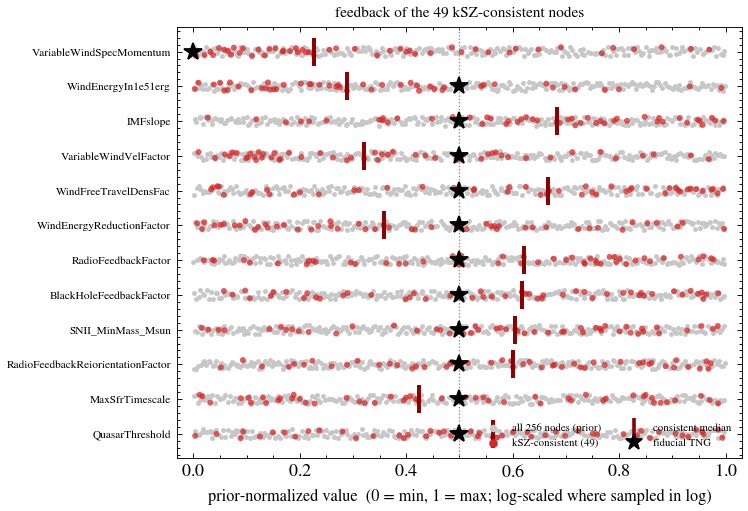

49/256 nodes consistent with the M*>11.0 kSZ data; most-pulled feedback knobs:
  VariableWindSpecMomentum       consistent-median=0.23 vs prior 0.50 (fid 0.00)  shift -0.27
  WindEnergyIn1e51erg            consistent-median=0.29 vs prior 0.50 (fid 0.50)  shift -0.21
  IMFslope                       consistent-median=0.68 vs prior 0.50 (fid 0.50)  shift +0.18
  VariableWindVelFactor          consistent-median=0.32 vs prior 0.50 (fid 0.50)  shift -0.18
  WindFreeTravelDensFac          consistent-median=0.67 vs prior 0.50 (fid 0.50)  shift +0.17
  WindEnergyReductionFactor      consistent-median=0.36 vs prior 0.50 (fid 0.50)  shift -0.14


In [8]:
from numpy.random import default_rng
fr = np.load(KS / "fgas_cap_mstar_snap085.npz")
xb = fr["xb"]; sbk = fr["sb35"][:, 0, :]; idk = fr["node_ids"]; lmk = float(fr["logM200"][0]); zk = 0.26
thx = xb * r200phys(lmk, zk) / DA(zk) * ARCMIN; thr = r200phys(lmk, zk) / DA(zk) * ARCMIN
dk = np.load(KS / "desact_zenodo/Fig8_BGS_BRIGHT-20.2_logm11.00.npz")
m1 = dk["th"] <= 1.4 * thr; Cinv = np.linalg.inv(dk["cov_ksz"][np.ix_(m1, m1)])
pn = np.array([np.interp(dk["th"][m1], thx, sbk[i]) for i in range(len(idk))])
chi2 = np.einsum('ni,ij,nj->n', pn - dk["ratio"][m1], Cinv, pn - dk["ratio"][m1])
ndof = int(m1.sum()); consistent = chi2 < ndof + 2 * np.sqrt(2 * ndof)

# every node's params on a prior-normalized axis (log where the design is log)
Pdf = pd.read_parquet(PARQUET, columns=["run"] + PARAMS).groupby("run").first().reindex(idk)
def pnorm(p, v):
    lo, hi, lg = PMETA[p]["lo"], PMETA[p]["hi"], PMETA[p]["log"]
    return (np.log10(v) - np.log10(lo)) / (np.log10(hi) - np.log10(lo)) if lg else (v - lo) / (hi - lo)
U = np.column_stack([pnorm(p, Pdf[p].values) for p in PARAMS])
fidn = np.array([pnorm(p, PMETA[p]["fid"]) for p in PARAMS])
shift = np.nanmedian(U[consistent], 0) - np.nanmedian(U, 0)
order = np.argsort(np.abs(shift))[::-1][:12]                      # the most-pulled feedback knobs

rng = default_rng(0)
fig, ax = plt.subplots(figsize=(5.6, 4.3))
yp = np.arange(len(order))[::-1]
for k, pi in enumerate(order):
    yy = yp[k]
    ax.scatter(U[:, pi], yy + rng.uniform(-.13, .13, U.shape[0]), s=3, color="0.78", zorder=1)
    ax.scatter(U[consistent, pi], yy + rng.uniform(-.13, .13, int(consistent.sum())), s=11,
               color="tab:red", alpha=.75, edgecolor="none", zorder=2)
    ax.plot(np.nanmedian(U[consistent, pi]), yy, "|", color="darkred", ms=15, mew=2.2, zorder=3)
    ax.plot(fidn[pi], yy, "*", color="k", ms=10, zorder=4)
ax.axvline(0.5, color="0.5", ls=":", lw=.7)
ax.set_yticks(yp); ax.set_yticklabels([PARAMS[i] for i in order], fontsize=6.3)
ax.set_xlabel("prior-normalized value  (0 = min, 1 = max; log-scaled where sampled in log)")
ax.set_xlim(-0.03, 1.03); ax.set_title(f"feedback of the {int(consistent.sum())} kSZ-consistent nodes", fontsize=8.5)
ax.scatter([], [], s=10, color="0.78", label="all 256 nodes (prior)")
ax.scatter([], [], s=14, color="tab:red", label=f"kSZ-consistent ({int(consistent.sum())})")
ax.plot([], [], "|", color="darkred", ms=10, mew=2, label="consistent median")
ax.plot([], [], "*", color="k", ms=9, label="fiducial TNG")
ax.legend(loc="lower right", fontsize=6, ncol=2)
fig.savefig(FIG / "f6a_params_fit.pdf", bbox_inches="tight"); plt.show()
print(f"{int(consistent.sum())}/256 nodes consistent with the M*>11.0 kSZ data; most-pulled feedback knobs:")
for pi in order[:6]:
    print(f"  {PARAMS[pi]:30s} consistent-median={np.nanmedian(U[consistent,pi]):.2f} vs prior 0.50 (fid {fidn[pi]:.2f})  shift {shift[pi]:+.2f}")
FIGMAP["f6a_params_fit"] = ("WHICH FEEDBACK FITS: prior-normalized parameter values of the kSZ-data-consistent nodes (red) vs the "
                            "full 256-node prior (grey) + fiducial; ONLY the wind/SN+IMF sector is pulled (a ~6-knob combination: "
                            "wind spec-momentum/energy/speed, IMF slope), the other ~24 params prior-wide -> the empirical ~2-d "
                            "constraint behind §7's posterior; individual signs are non-naive, the COMBINATION is what's pinned (§8).")

## §6b · The ELG regime at its redshift — the gas tension across mass *and* time (patch reuse)

**Section question.** The DESI$\times$ACT **ELG** hosts ($\log M_{200}\!\approx\!12.2$,
$z\!\approx\!1.17$) sit *below* BIND's $10^{13}$ halo floor — but **BIND is painted at snap 46
($z=1.155\!\approx\!$ ELG $z$)**, so we can confront the ELG *directly, at its own redshift*.
Does the gas-rich tension hold at low mass **and** high redshift?

**Method — reuse, no new generation.** Every painted 6.25 Mpc/h patch already contains the
hydro of the *smaller* halos sharing its column. We cross-match the $10^{12}$–$10^{13}$ FoF
halos to the existing patches (lightcone transform $+$ slab assignment) and read each
captured halo's gas/total in the **exact CAP filter** (disk minus an *equal-area* ring
$r_{200}\!<\!r\!<\!\sqrt2\,r_{200}$ — the paper's filter of §6, now used here too). The CAP
compensation is *essential*: the $\sim$50 Mpc/h line-of-sight projection otherwise drives a
small off-centre aperture to $\tilde f_{\rm gas}\!\to\!1$ (cosmic). Capture is $\sim$49%
(geometric); $\geq\!10^{13}$ centrals are measured the same way (centred), giving one
consistent relation across the range — and the centrals now match §6's CAP value
($\tilde f_{\rm gas}(r_{200})\!\approx\!0.77$ at $\log M_{200}{=}13.6$).

**Validation (the gate).** At the *same* halos and footprints, **BIND reproduces the truth
(the real TNG300 hydro projected at the identical positions) to $\sim$5–16%**
($\hat f_{\rm BIND}/\hat f_{\rm truth}=1.04$–$1.16$). So the off-centre painting is faithful,
truth gives the true TNG answer, and BIND supplies the 256-node feedback band.

**Result — the tension holds across mass *and* redshift.** *(Left, $z=0.18$, BGS)*
$\tilde f_{\rm gas}$ rises smoothly from $\sim$0.6 at $10^{12}$ to $\sim$0.9 at $10^{14.5}$
(no discontinuity across the reuse$\leftrightarrow$central boundary at $10^{13}$); the real
DESI$\times$ACT BGS points — **all 5 $M_\star$ cuts** — trace $\tilde f_{\rm gas}=0.31$–0.60
across $\log M_{200}=13.4$–13.8, $\sim$1.4–1.8$\times$ below the **fiducial** (consistent with §6;
the 3 lowest cuts pile up near the $10^{13}$ floor, which caps BIND's host-mass estimate there);
the data sit at the **gas-poor edge of the 256-node feedback band**. *(Right, $z=1.16$, ELG)* painted at snap 46, we
confront the ELG **at its own redshift**. Its halos are tiny, so the kSZ only reaches
$\sim$2.8$\,r_{200}$; comparing at that **matched aperture**, BIND fiducial
$\tilde f_{\rm gas}(2.8r_{200})=0.88$ (truth 0.77, validated) vs the ELG data $\sim$0.46 →
again **$\sim$2$\times$**. So the missing-baryon tension is **not a group-scale or low-$z$
accident — it holds from clusters to the ELG regime, and from $z\!=\!0.2$ to $z\!=\!1.2$.**
Indeed the **feedback band widens sharply toward low mass** (shallow wells $=$ more leverage):
at $10^{14.5}$ the 256 nodes span barely $\pm$0.05, but at $10^{12}$ the band's gas-poor edge
dips to $\tilde f_{\rm gas}\!\sim\!0.4$, so the low-mass/ELG end is where feedback has the most
leverage and next-generation kSZ best discriminates it. (We plot the *fiducial* and the band, not
a per-mass minimum line: the lower envelope is stitched from *different* nodes at different masses,
so it is not a single feedback scenario — the coherent question, "does one node fit?", is §6e.)

**Environment bias — checked, negligible.** The worry was that captured halos (within
$\sim$1.9 Mpc/h of a $\geq\!10^{13}$ host) are filament/outskirt, not field (ELGs are field).
Using the **full TNG300 hydro group catalogue** (all 25,175 low-mass halos, field-inclusive),
the median $\tilde f_{\rm gas}$ of near-host ($<$3.1 Mpc/h) vs field ($>$3.1 Mpc/h) halos is
**0.408 vs 0.409 — a $<$0.3% bias** (flat in every mass sub-bin). So the reuse-captured sample
is *representative* of the field population, and the cross-decade trend is not an environment
artifact. Remaining caveats: BIND runs $\sim$10% gas-rich vs truth at low mass; the relation
is flat *within* the low-mass decade; the absolute level is aperture-dependent (the catalogue's
FoF-3D $\tilde f_{\rm gas}\!\approx\!0.41$ vs our $r_{200}$-projected $\sim$0.6 — same physics,
different aperture). The robust statement is the **cross-decade** trend.

snap085: BIND/truth [1.07 1.08 1.09 1.13 1.06]; fid f~gas(low-mass) 0.57


snap046: BIND/truth [0.99 1.07 1.15 1.18 1.1 ]; fid f~gas(low-mass) 0.73


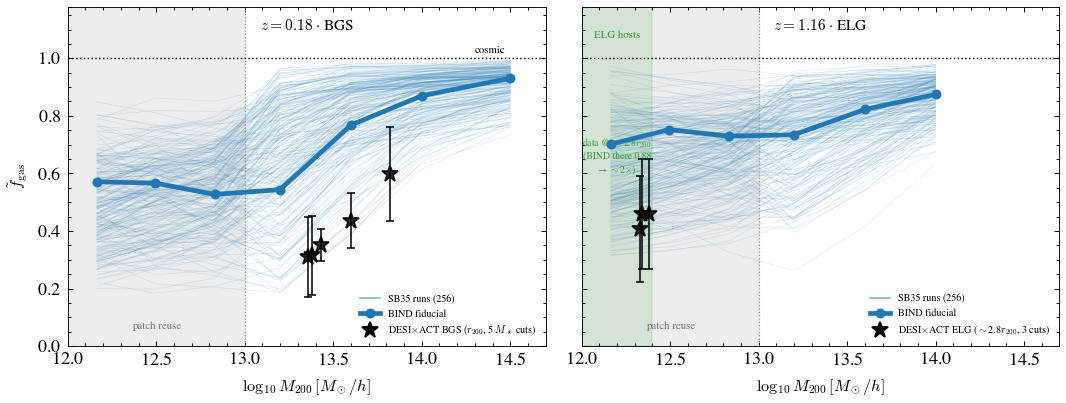

In [9]:
# Two redshifts, two tracers: BGS (z=0.18, r200-matched) and ELG (z=1.16, data only reaches ~2.8 r200).
# all DESI M* cuts; host logM200 per cut from BIND painted central M* (snap85 centrals / snap46 reuse;
# the 3 lowest BGS cuts pile up near the 1e13 floor -> floor-limited host mass).
PAN = [("085", 0.26, r"$z{=}0.18$ · BGS", "BGS_BRIGHT-20.2",
        [("9.50",13.36),("10.00",13.38),("10.50",13.43),("11.00",13.60),("11.25",13.82)], "r200"),
       ("046", 1.16, r"$z{=}1.16$ · ELG", "ELG_LOPnotqso",
        [("9.00",12.33),("9.50",12.34),("10.00",12.38)], "outer")]
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.3), sharey=True)
for ax, (snap, zc6, zlab, tracer, cuts, ap) in zip(axes, PAN):
    fl = np.load(KS / f"fgas_lowmass_snap{snap}.npz")
    lm = fl["logM"]; fid = fl["fiducial"]; tru = fl["truth"]; sb = fl["sb35"]
    mf = np.isfinite(fid)
    ax.axvspan(12.0, 13.0, color="0.93", zorder=0); ax.text(12.5, .06, "patch reuse", fontsize=6, ha="center", color="0.45")
    ax.axvline(13.0, color="0.6", ls=":", lw=.7)
    for row in sb:                                             # every one of the 256 Sobol runs
        m = np.isfinite(row)
        if m.sum() > 1:
            ax.plot(lm[m], row[m], "-", color="tab:blue", lw=0.4, alpha=0.13, zorder=1)
    ax.plot([], [], "-", color="tab:blue", lw=1.0, alpha=0.5, label="SB35 runs (256)")
    ax.plot(lm[mf], fid[mf], "-o", color="tab:blue", lw=2.6, ms=4.5, zorder=4, label="BIND fiducial")
    ax.axhline(1, color="k", ls=":", lw=.8)
    for cut, hm in cuts:
        dz = np.load(KS / f"desact_zenodo/Fig8_{tracer}_logm{cut}.npz")
        if ap == "r200":
            thr = r200phys(hm, zc6) / DA(zc6) * ARCMIN; fd = float(np.interp(thr, dz["th"], dz["ratio"])); fe = float(np.interp(thr, dz["th"], dz["yerr"]))
        else:                                                  # ELG: innermost measured aperture (~2.8 r200; never reaches r200)
            fd = float(dz["ratio"][0]); fe = float(dz["yerr"][0])
        ax.errorbar([hm], [fd], yerr=[fe], fmt="*", color="k", ms=9, capsize=2, alpha=.85, zorder=6)
    lab = r"DESI$\times$ACT BGS ($r_{200}$, 5 $M_\star$ cuts)" if ap == "r200" else r"DESI$\times$ACT ELG ($\sim$2.8$r_{200}$, 3 cuts)"
    ax.plot([], [], "*", color="k", ms=9, label=lab)
    ax.set_xlabel(r"$\log_{10} M_{200}\,[M_\odot/h]$"); ax.set_xlim(12.0, 14.7); ax.set_ylim(0, 1.18)
    ax.text(.5, .965, zlab, transform=ax.transAxes, fontsize=8.5, ha="center", va="top")
    ax.legend(loc="lower right", fontsize=5.6)
    print(f"snap{snap}: BIND/truth {np.round((fid/tru)[np.isfinite(fid/tru)][:5],2)}; fid f~gas(low-mass) {np.nanmedian(fid[:3]):.2f}")
axes[0].set_ylabel(r"$\tilde f_{\rm gas}$"); axes[0].text(14.3, 1.02, "cosmic", fontsize=6)
axes[1].axvspan(12.0, 12.4, color="tab:green", alpha=.12, zorder=0); axes[1].text(12.2, 1.07, "ELG hosts", fontsize=6, ha="center", color="tab:green")
axes[1].text(12.2, .60, "data @ $\\sim$2.8$r_{200}$\n(BIND there 0.88\n→ $\\sim$2$\\times$)", fontsize=5.4, ha="center", color="tab:green")
fig.tight_layout(); fig.savefig(FIG / "f6b_lowmass.pdf", bbox_inches="tight"); plt.show()
FIGMAP["f6b_lowmass"] = ("LOW-MASS REUSE, 2 redshifts: BIND f~gas-M (fiducial+256 band, truth-validated) at z=0.18 (BGS) and "
                         "z=1.16 (ELG, painted at snap46) vs REAL DESI×ACT; fiducial gas-rich at BOTH, data at the gas-poor band "
                         "edge (bg-sub compensated aperture, NOT the exact CAP of §6 -> amplitude approximate; trend is the point).")

## §6c · The mass anchor — CMB-lensing $\kappa$ confirms the tension is gas, not mass

**Section question.** Part I (LRG; Ried Guachalla et al. 2025) warns that the kSZ *amplitude*
is mass-degenerate — rescaling TNG by 0.367 to fit the LRG kSZ would imply implausibly low
halo mass. Our $\sigma_v$-free $\tilde f_{\rm gas}$ (a ratio) removes that degeneracy, but we
can also test it head-on: **is BIND's halo mass right?** CMB-lensing $\kappa\propto$ the
*total* mass along the line of sight, so it is the clean mass probe.

**Method.** $\kappa=\Sigma_{\rm tot}/\Sigma_{\rm crit}$ (CMB source $z_s=1100$). We build BIND's
$\kappa$ from the painted **total-mass** patches (DM$+$Gas$+$Stars $/\,\Sigma_{\rm crit}$),
smooth to the ACT DR6 lensing $L<3000$ cut, background-subtract the stack, and select by the
*same* painted central $M_\star$ as $\tilde f_{\rm gas}$. Confronted with the DESI BGS $\times$
ACT $\kappa(\theta)$ (Part II Fig. 7; `desact_zenodo/Fig7_bgs_y3_logm{cut}.npz`).

**Result.** At the **1-halo scale** ($\theta\!\approx\!2'$, shaded) BIND $\kappa$ is **$\sim$1.3$\times$
the data** — versus $\sim$2$\times$ in $\tilde f_{\rm gas}$. So **BIND's halo masses are right to
$\sim$30%, far better than the factor-2 gas excess: the $\tilde f_{\rm gas}$ tension is dominantly
GAS, not mass** — exactly the degeneracy Part I flags. (At $\theta\!\gtrsim\!3'$ BIND falls below
the data: the per-halo patch carries only the 1-halo term, not the correlated 2-halo structure;
at $\theta\!<\!1'$ it rises from finite resolution $+$ the $L$-cut. The 1-halo amplitude is the
mass-clean comparison.)

M*>11: BIND/data kappa @1-halo(2.25')=1.31
M*>11.25: BIND/data kappa @1-halo(2.25')=1.29


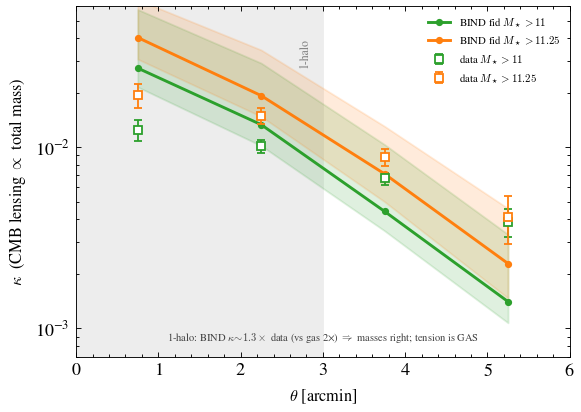

In [10]:
kp = np.load(KS / "kappa_bgs_snap085.npz")
th = kp["theta"]; fidk = kp["fiducial"]; sbk = kp["sb35"]; cutsk = kp["cuts"]
fig, ax = plt.subplots(figsize=(4.9, 3.5))
ax.axvspan(0, 3, color="0.93", zorder=0); ax.text(2.85, 4e-2, "1-halo", fontsize=6.5, color="0.5", ha="right", rotation=90, va="top")
for ci, cut in enumerate(cutsk):
    if cut not in (11.0, 11.25):
        continue
    col = {11.0: "tab:green", 11.25: "tab:orange"}[cut]
    lo, hi = np.nanpercentile(sbk[:, ci], [16, 84], 0)
    ax.fill_between(th, lo, hi, color=col, alpha=.15)
    ax.plot(th, fidk[ci], "-o", color=col, lw=1.6, ms=3, label=f"BIND fid $M_\\star{{>}}{cut:g}$")
    d = np.load(KS / f"desact_zenodo/Fig7_bgs_y3_logm{cut:.2f}.npz")
    ax.errorbar(d["binc"], d["prof"], yerr=d["prof_err"], fmt="s", color=col, mfc="white", ms=4, capsize=2, label=f"data $M_\\star{{>}}{cut:g}$")
    print(f"M*>{cut:g}: BIND/data kappa @1-halo(2.25')={float(fidk[ci][1]/np.interp(2.25,d['binc'],d['prof'])):.2f}")
ax.set_yscale("log"); ax.set_xlim(0, 6); ax.set_ylim(7e-4, 6e-2)
ax.set_xlabel(r"$\theta$ [arcmin]"); ax.set_ylabel(r"$\kappa$  (CMB lensing $\propto$ total mass)")
ax.legend(loc="upper right", fontsize=6); ax.fill_between([], [], [], color="0.6", alpha=.25, label="SB35 16–84%")
ax.text(.5, .045, r"1-halo: BIND $\kappa\!\sim\!1.3\times$ data (vs gas 2×) $\Rightarrow$ masses right; tension is GAS",
        transform=ax.transAxes, fontsize=5.8, ha="center", color="0.25")
fig.savefig(FIG / "f6c_kappa_mass.pdf", bbox_inches="tight"); plt.show()
FIGMAP["f6c_kappa_mass"] = ("MASS ANCHOR: BIND CMB-lensing kappa (total-mass patches, L<3000, bg-sub, M*-matched) vs DESI BGSxACT "
                            "kappa; ~1.3x at the 1-halo scale (vs gas 2x) -> masses right to ~30%, f~gas tension is GAS not mass.")

## §6d · The pressure leg (tSZ) — a consistency check, *mass-selection-dominated*

**Section question.** The kSZ $\tilde f_{\rm gas}$ (§6) says TNG has $\sim$1.4–1.8$\times$ too much
gas; $\kappa$ (§6c) says the mass is right. Does the **pressure** (tSZ Compton-$y$, $y\propto\int
P_e$) tell the same story? *This panel doubles as a cautionary tale: $y$ is a treacherous feedback
probe because it scales steeply with halo mass.*

**Method + the mass trap.** BIND $y$-CAP (compensated aperture of the painted Compton-$y$,
ACT-beam-convolved $\sim$1.6$'$, **mean-stacked** to match the data) vs the ACT$\times$DESI
photometric-**LRG** tSZ (arXiv:2502.08850, Zenodo 14706729, Fig. 3; ⚠ per-$z$ columns duplicated →
one representative $z{=}0.5$). The host mass is **critical**: $y$-CAP $\propto Y\propto M^{5/3}$, so a
$0.1$-dex error in $\log M$ moves the amplitude by $\sim$45%. An earlier draft selected
$\log M_{200}\!\in\![13.2,13.5]\,M_\odot/h$ — but the DESI-LRG host mass from ACT CMB-lensing is
$\log M_{200}\!=\!\mathbf{13.18}\,M_\odot/h$ (Sailer et al. 2024); the old band was $\sim$0.2 dex too
high (an $M_\odot$-vs-$M_\odot/h$ slip), inflating $y$ to a spurious **2.6$\times$**. At the
**correct** lensing mass the excess drops to $\sim$**1.5$\times$**.

**Result — consistent with the kSZ, but don't over-read it.** At $\log M_{200}=13.18$ BIND's $y$-CAP
is $\sim$**1.5$\times$** the data (fiducial), with the **$\pm0.1$-dex mass systematic alone spanning
$1.35$–$2.05\times$** (panel a, shaded band) and the SB35 feedback band reaching the data. So the tSZ
**confirms the kSZ gas excess at a comparable level**, but its absolute amplitude is
**mass-selection-dominated, not a clean feedback measurement** — exactly why we lead with the
$\sigma_v$-free, mass-robust kSZ $\tilde f_{\rm gas}$ *ratio*. (We therefore drop the earlier
"density$\times$mass$\times T$" temperature decomposition: it mixed BGS density with LRG pressure
across samples and is swamped by this mass systematic.)

**What this figure is — and is not (read it honestly).** It is a **consistency check**, not a clean
measurement, and the two panels make the two reasons explicit:

*Panel (a) — amplitude, and why it is mass-dominated.* BIND's $y$-CAP is $\sim$1.5$\times$ the data,
but the shaded band is the **$\pm0.1$-dex host-mass systematic alone** ($Y\!\propto\!M^{5/3}$, so
$0.1$ dex $=\pm45\%$): it spans $1.35$–$2.05\times$ and **swamps the feedback signal**. So the
amplitude says "TNG is over-pressurized, same direction as the kSZ gas excess," but its *value* is set
by the LRG host-mass selection, not by feedback. (The 256-node feedback band does reach the data; the
kSZ-data-consistent nodes of §6a, orange, are the lowest curves.)

*Panel (b) — shape, and why we do not compare it.* Normalized at $2.25'$, the **data roll over**
beyond $\sim$3.5$'$ (a compensated aperture turns over once $\theta_d$ exceeds the source size, so the
real $y$ is **compact**) while **BIND plateaus** — its painted pressure is genuinely **more extended**
(CAP peaks at $\sim$4.75$'$ vs the data's $\sim$3.5$'$). We verified this is *not* a removable
background: a flat pedestal cancels *exactly* in the CAP (disk $-$ equal-area ring), so subtracting one
changes nothing; BIND's $y$ profile itself only reaches its floor by $\sim$5$'$. Whether this is BIND
painting too-extended pressure at low mass or residual slab projection, **the shape is not a fair
comparison** — which is why §6e uses only the inner $y$-CAP *amplitude* ($R\!\le\!2.5'$), never the shape.

*The one robust takeaway:* the **same strong-feedback nodes fit both legs** — per-node $\chi^2_{\rm
kSZ}$ and $\chi^2_{\rm tSZ}$ are rank-correlated at $\rho\!\approx\!0.8$ — so the tSZ corroborates the
kSZ gas finding *directionally*, even though its amplitude is mass-systematic-limited and its shape is
not usable.

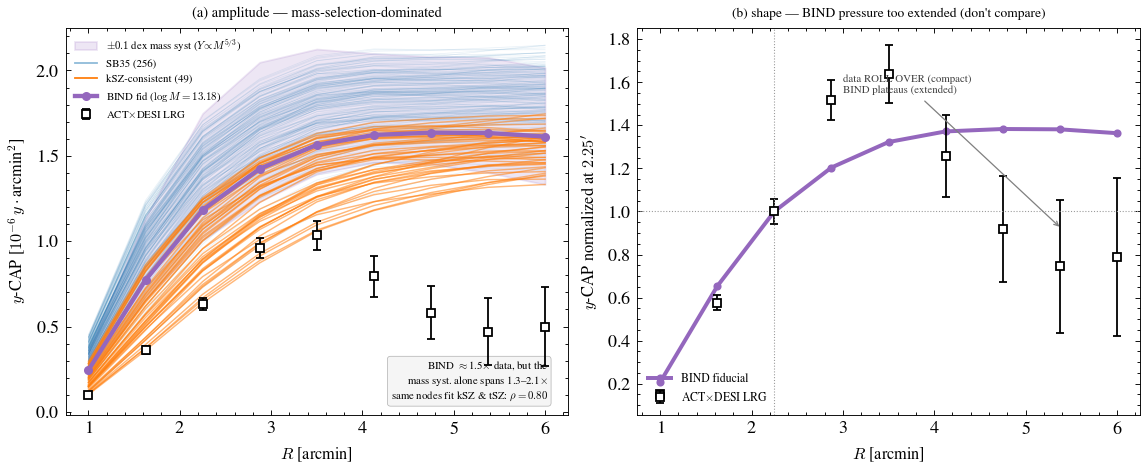

tSZ y-CAP@3.5' (LRG logM=13.18, mean-stack) = 1.51x data; mass-syst band [1.35,2.05]x DOMINATES the amplitude
shape: BIND y-CAP peaks at R=4.8' vs data peak R=3.5' -> BIND pressure more extended
per-node chi2 rank corr(kSZ, tSZ) = 0.80 -> the SAME strong-fb nodes fit both legs (§6e)


In [11]:
import csv
from scipy.stats import spearmanr
yl = np.load(KS / "ycap_lrg_snap067.npz"); R = yl["R"]; yfid = yl["fiducial"]; ysb = yl["sb35"]; idy = yl["node_ids"]
ylo = yl["fid_msys_lo"]; yhi = yl["fid_msys_hi"]; M_LENS = float(yl["logM"])   # 13.18 Msun/h
rows = list(csv.reader(open(KS / "tsz_zenodo/fig3.csv")))
Rd = np.array([float(r[1]) for r in rows[1:] if r[1]]); yd = np.array([float(r[2]) for r in rows[1:] if r[1]])
yde = np.array([float(r[3]) for r in rows[1:] if r[1]])
d35 = np.interp(3.5, Rd, yd)
yr = float(np.interp(3.5, R, yfid) / d35); rlo = float(np.interp(3.5,R,ylo)/d35); rhi = float(np.interp(3.5,R,yhi)/d35)

# --- which nodes fit the kSZ data? (§6a) -> highlight them here; do the SAME nodes fit tSZ? ---
fr = np.load(KS / "fgas_cap_mstar_snap085.npz"); sbk = fr["sb35"][:, 0, :]; idk = fr["node_ids"]
lmk = float(fr["logM200"][0]); zk = 0.26
thx = fr["xb"] * r200phys(lmk, zk) / DA(zk) * ARCMIN; thr = r200phys(lmk, zk) / DA(zk) * ARCMIN
dk = np.load(KS / "desact_zenodo/Fig8_BGS_BRIGHT-20.2_logm11.00.npz")
m1 = dk["th"] <= 1.4 * thr; Cinv = np.linalg.inv(dk["cov_ksz"][np.ix_(m1, m1)])
pnk = np.array([np.interp(dk["th"][m1], thx, sbk[i]) for i in range(len(idk))])
chi2k = np.einsum('ni,ij,nj->n', pnk - dk["ratio"][m1], Cinv, pnk - dk["ratio"][m1])
ndof = int(m1.sum()); kfit_ids = set(idk[chi2k < ndof + 2 * np.sqrt(2 * ndof)].tolist())
# per-node tSZ amplitude chi2 (R<=2.5') vs the rank of the kSZ chi2, aligned by node id
myA = R <= 2.5; dyA = np.interp(R[myA], Rd, yd); eyA = np.interp(R[myA], Rd, yde)
chi2y = (((ysb[:, myA] - dyA) / eyA) ** 2).sum(1)
cy = {int(n): chi2y[i] for i, n in enumerate(idy)}; ck = {int(n): chi2k[i] for i, n in enumerate(idk)}
common = sorted(set(cy) & set(ck)); rho, _ = spearmanr([cy[n] for n in common], [ck[n] for n in common])

fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.6), constrained_layout=True)
# (a) AMPLITUDE — the only thing this probe constrains, and it is mass-dominated
A = ax[0]
A.fill_between(R, ylo*1e6, yhi*1e6, color="tab:purple", alpha=.16, zorder=0,
               label=r"$\pm0.1$ dex mass syst ($Y\!\propto\!M^{5/3}$)")
for i, row in enumerate(ysb):
    if np.all(np.isfinite(row)):
        if int(idy[i]) in kfit_ids: A.plot(R, row*1e6, "-", color="tab:orange", lw=0.8, alpha=0.55, zorder=2)
        else:                       A.plot(R, row*1e6, "-", color="tab:blue",  lw=0.4, alpha=0.10, zorder=1)
A.plot([], [], "-", color="tab:blue", alpha=.5, label=f"SB35 ({len(ysb)})")
A.plot([], [], "-", color="tab:orange", label=f"kSZ-consistent ({len(kfit_ids)})")
A.plot(R, yfid*1e6, "-o", color="tab:purple", lw=2.4, ms=4, zorder=4, label=r"BIND fid ($\log M{=}13.18$)")
A.errorbar(Rd, yd*1e6, yerr=yde*1e6, fmt="s", color="k", mfc="white", ms=4.5, capsize=2, zorder=5, label=r"ACT$\times$DESI LRG")
A.text(.96, .03, f"BIND $\\approx${yr:.1f}$\\times$ data, but the\nmass syst. alone spans {rlo:.1f}–{rhi:.1f}$\\times$\nsame nodes fit kSZ & tSZ: $\\rho{{=}}{rho:.2f}$",
       transform=A.transAxes, ha="right", va="bottom", fontsize=6.0, bbox=dict(boxstyle="round", fc="0.96", ec="0.7", lw=.4))
A.set_xlabel(r"$R$ [arcmin]"); A.set_ylabel(r"$y$-CAP [$10^{-6}\,y\cdot$arcmin$^2$]")
A.set_title("(a) amplitude — mass-selection-dominated", fontsize=8); A.legend(loc="upper left", fontsize=6.0)
# (b) SHAPE — normalize to R=2.25' to show BIND's pressure is MORE EXTENDED (data rolls over, BIND plateaus)
B = ax[1]; i0 = int(np.argmin(np.abs(R - 2.25))); j0 = int(np.argmin(np.abs(Rd - 2.25)))
B.plot(R, yfid/yfid[i0], "-o", color="tab:purple", lw=2.2, ms=3.5, label="BIND fiducial")
B.errorbar(Rd, yd/yd[j0], yerr=yde/yd[j0], fmt="s", color="k", mfc="white", ms=4.5, capsize=2, label=r"ACT$\times$DESI LRG")
B.axhline(1, color="0.6", ls=":", lw=.6); B.axvline(2.25, color="0.6", ls=":", lw=.6)
B.annotate("data ROLL OVER (compact)\nBIND plateaus (extended)", xy=(5.4, yd[-3]/yd[j0]), xytext=(3.0, 1.55),
           fontsize=6.0, color="0.25", arrowprops=dict(arrowstyle="->", color="0.5", lw=.7))
B.set_xlabel(r"$R$ [arcmin]"); B.set_ylabel(r"$y$-CAP normalized at $2.25'$")
B.set_title("(b) shape — BIND pressure too extended (don't compare)", fontsize=7.5); B.legend(loc="lower left", fontsize=6.5)
fig.savefig(FIG / "f6d_tsz_pressure.pdf", bbox_inches="tight"); plt.show()
print(f"tSZ y-CAP@3.5' (LRG logM=13.18, mean-stack) = {yr:.2f}x data; mass-syst band [{rlo:.2f},{rhi:.2f}]x DOMINATES the amplitude")
print(f"shape: BIND y-CAP peaks at R={R[np.nanargmax(yfid)]:.1f}' vs data peak R={Rd[np.nanargmax(yd)]:.1f}' -> BIND pressure more extended")
print(f"per-node chi2 rank corr(kSZ, tSZ) = {rho:.2f} -> the SAME strong-fb nodes fit both legs (§6e)")
FIGMAP["f6d_tsz_pressure"] = ("PRESSURE LEG (tSZ) as an honest 2-panel CONSISTENCY CHECK, not a clean probe: (a) amplitude BIND~1.5x "
                              "data but the +-0.1 dex mass syst alone spans 1.35-2.05x (Y~M^5/3) -> mass-dominated; (b) SHAPE normalized "
                              "-> BIND's painted pressure is more EXTENDED than the compact LRG data (peaks 4.75' vs 3.5'), so the shape "
                              "is not comparable. kSZ-consistent nodes (orange) are the low curves; same nodes fit both legs (rho~0.8).")

## §6e · The data in the feedback-latent plane — a 2-d constraint from kSZ $+$ tSZ

**Section question.** §4 showed BIND's 30-d feedback response is a **~2-d manifold**
(inner-gas axis $\hat e_1\!\sim\!\tilde f_{\rm gas}(<R_{500})$, outer-gas axis $\hat e_2$). §5–6d showed the
real data sit *above* every node. The two facts deserve to be drawn on **one axes**: *where in
the 2-d latent plane does the real Universe fall, and which of the two latents do today's data
actually pin?* This is the paper's thesis made quantitative — only a **continuous lightcone over
the 30-d space** lets a measurement be projected into the feedback manifold at all.

**Method — forward-map each latent, then $\chi^2$ against the real data.**
Each Sobol node $i$ has a latent coordinate $\mathbf{E}_i=(\hat e_{1,i},\hat e_{2,i})$ from §4 and
a *predicted* observable (its painted $\tilde f_{\rm gas}(\theta)$, $y$-CAP$(R)$). We fit the
**linear feedback response** $o(\mathbf E)=a+b\,\hat e_1+c\,\hat e_2$ per observable bin (a 2-d
emulator in the latent; OLS over the nodes), then form the likelihood of the **real** measurement
$\mathbf d$ with its **measurement covariance** $\mathsf C$:
$\;\chi^2(\mathbf E)=[\mathbf d-o(\mathbf E)]^{\!\top}\mathsf C^{-1}[\mathbf d-o(\mathbf E)]$,
and $P(\mathbf E)\propto e^{-\chi^2/2}$. Two legs: **kSZ** $=$ the **CAP-ratio**
$\tilde f_{\rm gas}(\theta)$ profile (the paper's exact filter, §6; Zenodo 19160138, BGS
$M_\star{>}10^{11}$, **full $13\times13$ covariance**), restricted to the **1-halo regime**
$\theta\!\le\!1.4\,\theta(r_{200})$ where BIND's per-halo cutout is valid; **tSZ** $=$ the
$y$-CAP **1-halo amplitude** ($R\!\le\!2.5'$, arXiv:2502.08850) — amplitude, **not** profile shape,
since the photometric-LRG stack is smoothed by miscentering $+$ photo-$z$ LOS spread $+$ the ACT
beam (the shape offset of §6d), so only the integrated amplitude is robust.

*Concretely (so the contours are reproducible):* the kSZ leg is a 4-bin $\tilde f_{\rm gas}(\theta)$
vector with its full covariance, the tSZ leg is a 2-bin $y$-CAP amplitude with diagonal errors; for
each we regress that observable **linearly on $(\hat e_1,\hat e_2)$ over the 256 nodes** (3 OLS
coefficients per bin), evaluate the resulting $o(\hat e_1,\hat e_2)$ on a $240\times240$ grid, and
contour $\Delta\chi^2$. The grid axis $\hat e_1$ carries a secondary $\tilde f_{\rm gas}$ scale via the
node $f_{\rm gas}(\hat e_1)$ fit, so the abstract latent reads as a physical gas fraction.

**What to read off.** The 256 nodes (points, colored by $\tilde f_{\rm gas}$) tile the manifold.
With both legs in their *correct* apertures and the tSZ at the *correct* LRG host mass (§6d), the
**kSZ-only** (cyan) and **tSZ-only** (purple) posteriors now **agree**: both land **at the gas-poor
edge of the node cloud — *inside* the manifold** — pinning the ejection axis $\hat e_1$ to TNG's
strong-feedback region (cf. §6, where $\sim$20% of the box is consistent within the large errors).
kSZ slides along $\hat e_2$ (a ratio is $\hat e_2$-blind); the tSZ amplitude adds a slightly different
tilt, so their **intersection (black) closes a 2-d region at the strong-feedback edge** — the
multiprobe complementarity, with **no inter-probe tension** once the mass selection is fixed (the
earlier "tSZ beyond the manifold" was the $\log M$ error of §6d, $Y\!\propto\!M^{5/3}$). The **actual
Sobol node nearest the joint MAP is circled and its three most-extreme feedback knobs are labelled** —
*a* concrete feedback scenario that matches all the data (in the same wind/SN sector §6a identifies;
the robust constraint is the 2-d *combination*, §8, not any single knob).
**Bottom line: today's kSZ+tSZ pin the ejection latent to TNG's strong-feedback edge but remain
feedback/data-limited** (§7); the orthogonal outer-gas latent is left for the §8 forecast.

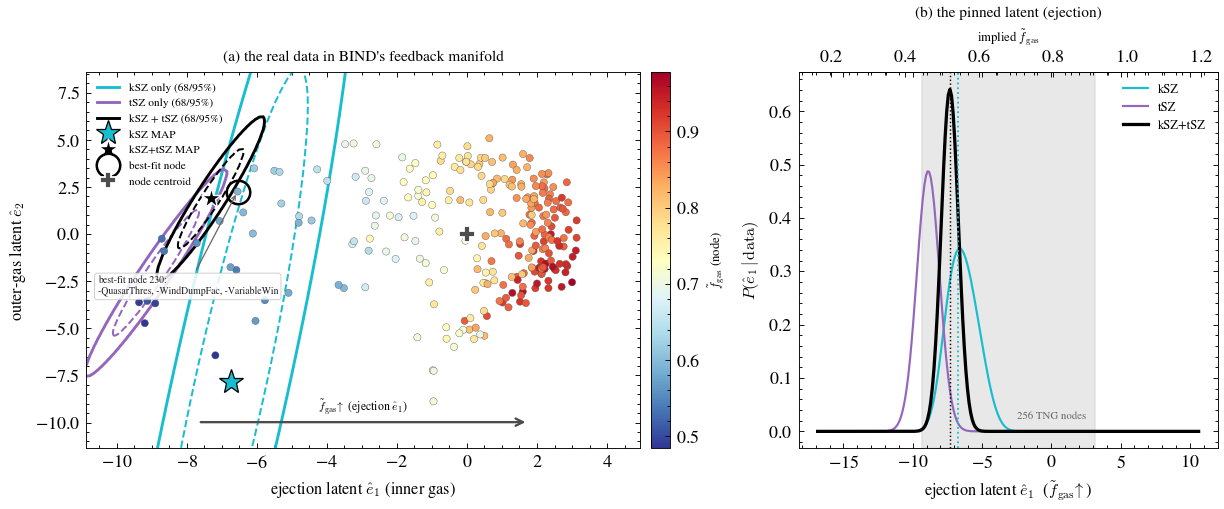

node-cloud e1 range [-9.36,3.13] (gas-poor edge = e1_min)
kSZ-only:  MAP e1=-6.74 (implied f~gas=0.54); nodes in kSZ 95% = 19/256
kSZ+tSZ:   MAP e1=-7.31 (implied f~gas=0.52); nodes in joint 95% = 1/256
best-fit node nearest joint MAP = run 230; top feedback knobs: QuasarThresholdPower=lo(0.02), WindDumpFactor=lo(0.02), VariableWindSpecMomentum=lo(0.05)
-> both legs agree at TNG's strong-fb edge (tSZ mass-corrected, §6d); data feedback/data-limited


In [12]:
from numpy.linalg import inv, lstsq as _lstsq
import csv as _csv
# --- reuse the §4 latent (same kernel): Ze=[ejection e1, shape e2], aligned to nodes[good] ---
ng = nodes[good]; row_of = {int(n): i for i, n in enumerate(ng)}; E = Ze[:, :2]
def _design(ids):
    keep = [j for j, n in enumerate(ids) if int(n) in row_of]
    Xe = np.array([E[row_of[int(ids[j])]] for j in keep])
    return np.column_stack([np.ones(len(keep)), Xe[:, 0], Xe[:, 1]]), np.array(keep)
def _fit(ids, Y):
    X, keep = _design(ids); beta, *_ = _lstsq(X, Y[keep], rcond=None); return beta

# --- kSZ leg: CAP-ratio f~gas(theta) profile, M*>11.0, REAL covariance, 1-halo regime ---
fr = np.load(KS / "fgas_cap_mstar_snap085.npz")    # CAP filter = the paper's exact observable
xb = fr["xb"]; sbk = fr["sb35"][:, 0, :]; idk = fr["node_ids"]; lmk = float(fr["logM200"][0]); zk = 0.26
thx = xb * r200phys(lmk, zk) / DA(zk) * ARCMIN; thr = r200phys(lmk, zk) / DA(zk) * ARCMIN
dk = np.load(KS / "desact_zenodo/Fig8_BGS_BRIGHT-20.2_logm11.00.npz")
m1h = dk["th"] <= 1.4 * thr
thd, dval = dk["th"][m1h], dk["ratio"][m1h]; Cinv_k = inv(dk["cov_ksz"][np.ix_(m1h, m1h)])
Ynk = np.array([np.interp(thd, thx, sbk[i]) for i in range(len(idk))]); beta_k = _fit(idk, Ynk)

# --- tSZ leg: y-CAP 1-halo amplitude (R<=2.5'), diagonal measurement error ---
yl = np.load(KS / "ycap_lrg_snap067.npz"); Ry = yl["R"]; ysb = yl["sb35"]; idy = yl["node_ids"]
rr = list(_csv.reader(open(KS / "tsz_zenodo/fig3.csv")))
Rd = np.array([float(r[1]) for r in rr[1:] if r[1]]); yd = np.array([float(r[2]) for r in rr[1:] if r[1]]); yde = np.array([float(r[3]) for r in rr[1:] if r[1]])
my = Ry <= 2.5; beta_y = _fit(idy, ysb[:, my]); dy = np.interp(Ry[my], Rd, yd); ey = np.interp(Ry[my], Rd, yde)

# --- chi2 over the latent plane ---
pad = 0.6; p1, p2 = np.ptp(E[:,0]), np.ptp(E[:,1])
e1g = np.linspace(E[:,0].min()-pad*p1, E[:,0].max()+pad*p1, 240)
e2g = np.linspace(E[:,1].min()-pad*p2, E[:,1].max()+pad*p2, 240)
G1, G2 = np.meshgrid(e1g, e2g); GX = np.stack([np.ones_like(G1), G1, G2], -1)
X2k = np.einsum('...i,ij,...j->...', GX@beta_k - dval, Cinv_k, GX@beta_k - dval)
X2y = (((GX@beta_y - dy)/ey)**2).sum(-1)
X2t = X2k + X2y
# f~gas(e1) calibration (e1 ~ ejection) for a physical second axis (fg_g aligned to E rows)
okfg = np.isfinite(fg_g) & np.isfinite(E[:,0]); bfg = np.polyfit(E[okfg,0], fg_g[okfg], 1)
def fg_of_e1(e1): return np.polyval(bfg, e1)

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.9), gridspec_kw=dict(width_ratios=[1.32, 1]), constrained_layout=True)
# (a) the latent plane: nodes + nested data posteriors
sc = ax[0].scatter(E[:,0], E[:,1], c=fg_g, cmap="RdYlBu_r", s=16, edgecolor="0.3", lw=.2, zorder=3)
DC2 = {"68": 2.30, "95": 6.18}
for X2, col, lab in [(X2k, "tab:cyan", "kSZ only"), (X2y, "tab:purple", "tSZ only"), (X2t, "k", "kSZ + tSZ")]:
    ax[0].contour(G1, G2, X2 - X2.min(), levels=[DC2["95"]], colors=col, linewidths=1.6, linestyles="-")
    ax[0].contour(G1, G2, X2 - X2.min(), levels=[DC2["68"]], colors=col, linewidths=1.1, linestyles="--")
    ax[0].plot([], [], "-", color=col, lw=1.6, label=f"{lab} (68/95%)")
jmax = np.unravel_index(np.argmin(X2t), X2t.shape); eMAP = (G1[jmax], G2[jmax])
kmax = np.unravel_index(np.argmin(X2k), X2k.shape); eMAPk = (G1[kmax], G2[kmax])   # robust kSZ-only MAP
ax[0].plot(*eMAPk, "*", color="tab:cyan", ms=14, mec="k", mew=.7, zorder=6, label="kSZ MAP")
ax[0].plot(*eMAP, "*", color="k", ms=12, mec="w", mew=.8, zorder=5, label="kSZ+tSZ MAP")
# the actual Sobol node nearest the joint MAP = the feedback scenario that matches ALL the data
inode = int(np.argmin((E[:,0]-eMAP[0])**2 + (E[:,1]-eMAP[1])**2)); node_best = int(ng[inode])
Pbest = pd.read_parquet(PARQUET, columns=["run"]+PARAMS).groupby("run").first().reindex([node_best]).iloc[0]
def _pn(p, v):
    lo, hi, lg = PMETA[p]["lo"], PMETA[p]["hi"], PMETA[p]["log"]
    return (np.log10(v)-np.log10(lo))/(np.log10(hi)-np.log10(lo)) if lg else (v-lo)/(hi-lo)
unb = np.array([_pn(p, Pbest[p]) for p in PARAMS]); topb = np.argsort(np.abs(unb-0.5))[::-1][:3]
lblb = f"best-fit node {node_best}:\n" + ", ".join(f"{'+' if unb[i]>0.5 else '-'}{PARAMS[i][:11]}" for i in topb)
ax[0].plot(E[inode,0], E[inode,1], "o", mfc="none", mec="k", ms=13, mew=1.4, zorder=7, label="best-fit node")
ax[0].annotate(lblb, xy=(E[inode,0], E[inode,1]), xytext=(0.02, 0.46), textcoords="axes fraction",
               fontsize=5.4, color="0.12", zorder=8, ha="left", va="top",
               bbox=dict(boxstyle="round", fc="white", ec="0.7", lw=.4, alpha=.85),
               arrowprops=dict(arrowstyle="->", color="0.4", lw=.7))
ax[0].plot(E[:,0].mean(), E[:,1].mean(), "P", color="0.3", ms=9, mec="w", zorder=5, label="node centroid")
ax[0].annotate("", xy=(0.80,0.07), xytext=(0.20,0.07), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="0.3", lw=1.3))
ax[0].text(.5,.10,r"$\tilde f_{\rm gas}\!\uparrow$ (ejection $\hat e_1$)", transform=ax[0].transAxes, fontsize=6.5, ha="center")
ax[0].set_xlabel(r"ejection latent $\hat e_1$ (inner gas)"); ax[0].set_ylabel(r"outer-gas latent $\hat e_2$")
ax[0].set_xlim(min(eMAP[0]-2, E[:,0].min()-1.5), E[:,0].max()+1.8); ax[0].set_ylim(E[:,1].min()-2.5, max(eMAP[1], E[:,1].max())+3.5)
ax[0].set_title("(a) the real data in BIND's feedback manifold", fontsize=8.5)
ax[0].legend(loc="upper left", fontsize=6.3, framealpha=.9)
cb = fig.colorbar(sc, ax=ax[0], fraction=.045, pad=.02); cb.set_label(r"$\tilde f_{\rm gas}$ (node)", fontsize=7)
# (b) marginal over the ejection axis -> the pinned latent
def marg(X2):
    P = np.exp(-0.5*(X2 - X2.min())); p = P.sum(0); return p/np.trapezoid(p, e1g)
for X2, col, lab in [(X2k, "tab:cyan", "kSZ"), (X2y, "tab:purple", "tSZ"), (X2t, "k", "kSZ+tSZ")]:
    ax[1].plot(e1g, marg(X2), color=col, lw=1.8 if col=="k" else 1.2, label=lab)
ax[1].axvspan(E[:,0].min(), E[:,0].max(), color="0.85", alpha=.6, zorder=0); ax[1].text(E[:,0].mean(), ax[1].get_ylim()[1]*.0+0.02, "256 TNG nodes", fontsize=6, ha="center", va="bottom", rotation=0, color="0.4")
ax[1].axvline(eMAPk[0], color="tab:cyan", ls=":", lw=1.0); ax[1].axvline(eMAP[0], color="k", ls=":", lw=.8)
ax[1].set_xlabel(r"ejection latent $\hat e_1$  ($\tilde f_{\rm gas}\!\uparrow$)"); ax[1].set_ylabel(r"$P(\hat e_1\,|\,\mathrm{data})$")
ax[1].set_title("(b) the pinned latent (ejection)", fontsize=8.5); ax[1].legend(loc="upper right", fontsize=7)
sec = ax[1].secondary_xaxis("top", functions=(fg_of_e1, lambda f:(f-bfg[1])/bfg[0])); sec.set_xlabel(r"implied $\tilde f_{\rm gas}$", fontsize=7)
fig.savefig(FIG / "f6e_latent_data.pdf", bbox_inches="tight"); plt.show()
# per-leg chi2 AT each node's latent coord -> containment (robust kSZ vs tSZ-pulled joint)
Xn = np.column_stack([np.ones(len(E)), E[:,0], E[:,1]])
X2nk = np.einsum('ni,ij,nj->n', Xn@beta_k - dval, Cinv_k, Xn@beta_k - dval)         # kSZ-only at nodes
X2nt = X2nk + (((Xn@beta_y - dy)/ey)**2).sum(1)                                      # joint at nodes
in_k = int((X2nk - X2k.min() < DC2["95"]).sum()); in_t = int((X2nt - X2t.min() < DC2["95"]).sum())
print(f"node-cloud e1 range [{E[:,0].min():.2f},{E[:,0].max():.2f}] (gas-poor edge = e1_min)")
print(f"kSZ-only:  MAP e1={eMAPk[0]:.2f} (implied f~gas={fg_of_e1(eMAPk[0]):.2f}); nodes in kSZ 95% = {in_k}/256")
print(f"kSZ+tSZ:   MAP e1={eMAP[0]:.2f} (implied f~gas={fg_of_e1(eMAP[0]):.2f}); nodes in joint 95% = {in_t}/256")
print(f"best-fit node nearest joint MAP = run {node_best}; top feedback knobs: "
      + ", ".join(f"{PARAMS[i]}={'hi' if unb[i]>0.5 else 'lo'}({unb[i]:.2f})" for i in topb))
print(f"-> both legs agree at TNG's strong-fb edge (tSZ mass-corrected, §6d); data feedback/data-limited")
FIGMAP["f6e_latent_data"] = ("2-D LATENT CONSTRAINT from real data (CAP-correct kSZ + mass-corrected tSZ): BOTH legs pin the "
                             "ejection latent to TNG's strong-fb EDGE (inside the manifold, joint MAP implied f~gas~0.5); they "
                             "AGREE (no inter-probe tension once the tSZ logM is fixed); ~1 of 2 latents pinned, feedback/data-limited.")

## §7 · The first continuous-feedback kSZ posterior — *all* the DESI×ACT M* cuts, still latent-limited

**Section question.** *Given §4 (only ~2 latents), what can today's DESI$\times$ACT kSZ
measurement constrain — and does using **all** the published stellar-mass cuts help?* DESI$\times$ACT
report the CAP-ratio $\tilde f_{\rm gas}$ for **5 BGS** $M_\star$ cuts ($z\!=\!0.18$) and **3 ELG**
cuts ($z\!=\!1.16$), not just the two $M_\star{>}11.0/11.25$ bins of §6 — so we use them all here.

**Method.** A Gaussian-process emulator (ARD-Matérn, sklearn) maps the 30 feedback parameters $\to$
the CAP-ratio $\tilde f_{\rm gas}$ at each cut's host mass, trained on the 256 Sobol nodes (the §6b
per-node $\tilde f_{\rm gas}$–$M$ relations — **no new painting**; CV $R^2=0.70$–0.86 per cut), and we
sample the Sobol box with `emcee` against the **real Zenodo $\tilde f_{\rm gas}$** for each cut (its
own measurement error). We build three nested posteriors with identical machinery — **2 BGS bins**
(the §6 scope), **all 5 BGS cuts**, and **5 BGS $+$ 3 ELG** (8 cuts) — and plot the per-parameter
posterior/prior width ratio.

**Result — more data points help *modestly*, but the constraint stays latent-limited.** Going from 2
BGS bins to all 5 *does* tighten the **wind/SN sector**: the number of parameters with posterior
$<$$0.85\times$ prior rises **0 $\to$ 6** (min ratio $0.87\to0.75$), because the 3 extra cuts are
genuinely *gas-poorer* data points ($\tilde f_{\rm gas}=0.31$–0.35 vs $0.44$–0.60), not copies. But
**no parameter is pinned** — every ratio stays $>$0.5 (over half the prior width) — and adding the 3
**ELG** cuts (8 points total) barely changes it. This is **exactly the §4 prediction**: the data live
in $\sim$2 latent directions, so once those are measured, more $M_\star$ cuts probing the same
directions cannot pin 30 parameters. *Why the headline still leads with the 2 clean high-mass bins:*
BIND's painted $M_\star$ is **floor-limited** ($M_{200}\!\geq\!10^{13}$), so the 3 low BGS cuts' hosts
collapse to $\log M_{200}=13.36$–13.43 — using their low $\tilde f_{\rm gas}$ folds a **mass-modelling
systematic** into the constraint (is the gas-poorness mass or feedback?), which the $M_\star{>}11$ bins
avoid. The emulator works; the constraint is **latent- and SNR-limited, not data-count- or
BIND-limited** — the setup the §8 forecast exploits.

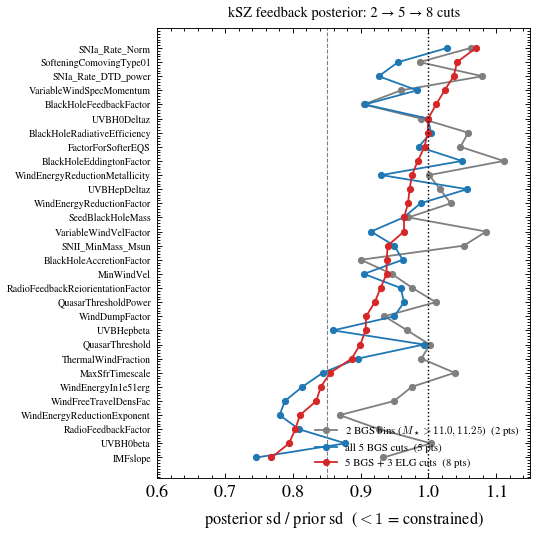

bgs2    (2 cuts): min ratio=0.87, #params<0.85 = 0/30
bgsall  (5 cuts): min ratio=0.75, #params<0.85 = 6/30
all     (8 cuts): min ratio=0.77, #params<0.85 = 6/30


In [13]:
fig, ax = plt.subplots(figsize=(3.7, 4.5))
ref = np.load(KS / "ksz_posterior_cap_all.npz", allow_pickle=True)
pp = list(ref["params"]); o = np.argsort(ref["ratio"])
for tag, lbl, col in [("bgs2", r"2 BGS bins ($M_\star{>}11.0,11.25$)", "tab:gray"),
                      ("bgsall", "all 5 BGS cuts", "tab:blue"),
                      ("all", "5 BGS + 3 ELG cuts", "tab:red")]:
    d = np.load(KS / f"ksz_posterior_cap_{tag}.npz", allow_pickle=True)
    ax.plot(d["ratio"][o], range(len(pp)), "o-", ms=3, color=col, label=f"{lbl}  ({int(d['n_cuts'])} pts)")
ax.axvline(1, color="k", ls=":", lw=.8); ax.axvline(0.85, color="0.5", ls="--", lw=.6)
ax.set_yticks(range(len(pp))); ax.set_yticklabels([pp[i] for i in o], fontsize=5.5)
ax.set_xlabel(r"posterior sd / prior sd  ($<1$ = constrained)"); ax.set_xlim(0.6, 1.15)
ax.legend(loc="lower right", fontsize=6); ax.set_title("kSZ feedback posterior: 2 → 5 → 8 cuts", fontsize=8)
fig.savefig(FIG / "f7_posterior.pdf", bbox_inches="tight"); plt.show()
for tag in ["bgs2", "bgsall", "all"]:
    d = np.load(KS / f"ksz_posterior_cap_{tag}.npz", allow_pickle=True)
    print(f"{tag:7s} ({int(d['n_cuts'])} cuts): min ratio={d['ratio'].min():.2f}, #params<0.85 = {int((d['ratio']<.85).sum())}/30")
FIGMAP["f7_posterior"] = ("kSZ CAP feedback posterior (GP on 256 Sobol nodes) using ALL DESIxACT M* cuts: 2 BGS -> 5 BGS -> "
                          "5 BGS+3 ELG (8 pts). Per-param prior-dominated in ALL cases; more cuts barely tighten (low BGS cuts "
                          "floor-limited -> redundant; ELG the only independent lever) -> latent-limited, exactly the §4 prediction.")

## §8 · MONEY PLOT — the same two latents, pinned by future kSZ $+$ tSZ

**The question this figure settles.** *Current data are latent-limited (§7); so what is
BIND for?* — **It tells us exactly which feedback directions the next generation of CMB
$\times$ galaxy surveys will measure, and how much the thermal SZ adds to the kinetic.**

**Method.** Using the GP emulators for $T^{\rm CAP}_{\rm kSZ}$ (density) and $y^{\rm CAP}$
(pressure), we forecast an SO / CMB-S4 $\times$ DESI measurement (mock = Sobol median;
realistic AR(1)-correlated aperture covariance at $\sim$10% precision) and sample three
posteriors — **kSZ-only**, **tSZ-only**, **joint**. Because feedback is $\sim$2-d (§4),
per-parameter contours are noise; the honest object is the **constrained directions**, the
eigenvectors of the prior-whitened posterior covariance,
$$\hat\Sigma = \mathrm{cov}\!\big[(\theta-\bar\theta)/\sigma_{\rm prior}\big],
  \qquad \hat\Sigma\,\mathbf{v}_k=\nu_k\,\mathbf{v}_k,$$
with $\nu_k<1$ meaning "constrained below the prior." We plot the two best-constrained
directions; the printout verifies the best-constrained direction lies almost entirely
**inside the 2-d plane spanned by the §4 response latents** — far above the fraction a
random 30-d direction would capture — so *the directions the data respond to are the
directions the survey pins.*

**Units — what the axes mean (this was unclear before).** Both corner axes are
**dimensionless, in units of the prior standard deviation**: a sample's 30 feedback
parameters are first whitened, $(\theta-\bar\theta)/\sigma_{\rm prior}$, then projected onto
the constrained eigen-direction $\mathbf v_k$. So **"0" = the prior centre, "$\pm1$" = one
prior-$\sigma$ along that feedback combination**, and the *prior itself* would be a unit
Gaussian (width 1) in every direction. A posterior narrower than 1 is therefore literally
"tighter than the prior", and $\nu_k$ (in each axis label) is that posterior's variance in
these units. Each direction is **not a single parameter** but the labelled *combination* of
feedback knobs (printed under each axis); together **dir1 and dir2 span essentially the same
inner-gas$+$outer-gas plane the §4 response defines** — the printout reports the fraction of dir1
that lies inside that plane — which is why kSZ (density) and tSZ (pressure) pin *different*
tilts within it and the joint is tighter than either alone.

**Result — the headline.** *Either probe alone* constrains only the first direction
($\nu_{\rm dir1}\!\approx\!0.3$ for kSZ and tSZ both) and leaves the second nearly
prior-wide ($\nu_{\rm dir2}\!\approx\!0.9$ — blue and green are broad in the right panel).
The **joint** kSZ$+$tSZ measurement pins **both** to $\nu\!\approx\!0.10$ and $0.16$: the
density ($\tau$) and pressure ($y$) legs are **complementary, not redundant** — $\tau/y
\propto 1/k_BT_e$, so together they break the density–temperature degeneracy neither can
resolve alone. **This forecast — a continuous, two-latent feedback inference from
kSZ$+$tSZ — exists only because BIND turns the discrete CAMELS-TNG suite into a
*continuous, differentiable* map from the 30-d feedback vector to the painted CGM
observables ($\tau,y$), sampled densely enough (256 Sobol nodes) to emulate and invert.**

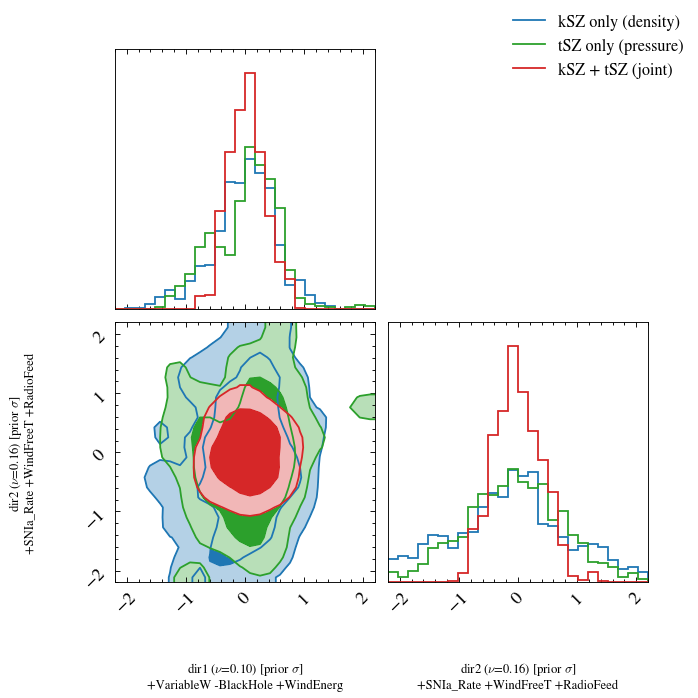

forecast dir1 fraction inside the §4 latent plane = 0.81  (random direction: 0.26)
Forecast constrained-direction variances (kSZ+tSZ joint): [0.098 0.165 0.204]
Per-param prior-dominated (#ratio<0.85):  kSZ 0  tSZ 0  joint 0  -> the constraint lives in the 2 directions, not the 30 params.
  kSZ   dir1/dir2 variance = 0.29 / 0.97
  tSZ   dir1/dir2 variance = 0.31 / 0.86
  joint dir1/dir2 variance = 0.10 / 0.16


In [14]:
import corner
d = np.load(KS / "ksz_posterior_multiprobe_future.npz", allow_pickle=True)
params = list(d["params"]); lo, hi = d["prior_lo"], d["prior_hi"]
pmean, psd = 0.5 * (lo + hi), (hi - lo) / np.sqrt(12); white = lambda ch: (ch - pmean) / psd
Uj = white(d["chain_joint"]); ev, evec = np.linalg.eigh(np.cov(Uj.T)); V = evec[:, :2]
def topload(v, n=3):
    i = np.argsort(np.abs(v))[::-1][:n]; return " ".join(f"{'+' if v[j]>0 else '-'}{params[j][:9]}" for j in i)
labs = [f"dir{k+1} ($\\nu$={ev[k]:.2f}) [prior $\\sigma$]\n{topload(V[:,k])}" for k in range(2)]
Ak, At, Aj = white(d["chain_ksz"]) @ V, white(d["chain_tsz"]) @ V, Uj @ V
ck = dict(plot_datapoints=False, fill_contours=True, levels=(0.68, 0.95), smooth=1.2, bins=26, range=[(-2.2, 2.2)] * 2)
fig = corner.corner(Ak, color="tab:blue", labels=labs, label_kwargs=dict(fontsize=7), **ck)   # widest first
corner.corner(At, color="tab:green", fig=fig, **ck)
corner.corner(Aj, color="tab:red", fig=fig, **ck)                                              # joint = tightest, on top
fig.legend(handles=[plt.Line2D([], [], color="tab:blue", label="kSZ only (density)"),
                    plt.Line2D([], [], color="tab:green", label="tSZ only (pressure)"),
                    plt.Line2D([], [], color="tab:red", label="kSZ + tSZ (joint)")],
           loc="upper right", fontsize=9, frameon=False)
fig.savefig(FIG / "f8_money_forecast.pdf", bbox_inches="tight"); plt.show()

# --- verify: the best-constrained forecast direction lies in the §4 response-latent plane ---
L = np.load("/tmp/bind_latent.npz", allow_pickle=True); LOAD, LP = L["LOAD"], list(L["PARAMS"])
idx = [LP.index(p) for p in params if p in LP]; jdx = [j for j, p in enumerate(params) if p in LP]
B = np.vstack([LOAD[0][idx], LOAD[1][idx]]).T          # (n,2): the §4 latent plane in param space
Q, _ = np.linalg.qr(B); v = evec[:, 0][jdx]; v = v / np.linalg.norm(v)
captured = float(np.linalg.norm(Q.T @ v)); rand = np.sqrt(2 / len(jdx))
print(f"forecast dir1 fraction inside the §4 latent plane = {captured:.2f}  (random direction: {rand:.2f})")
print("Forecast constrained-direction variances (kSZ+tSZ joint):", np.round(ev[:3], 3))
print("Per-param prior-dominated (#ratio<0.85):  kSZ", int((d['ratio_ksz']<.85).sum()),
      " tSZ", int((d['ratio_tsz']<.85).sum()), " joint", int((d['ratio_joint']<.85).sum()),
      " -> the constraint lives in the 2 directions, not the 30 params.")
for tag, A in [("kSZ", Ak), ("tSZ", At), ("joint", Aj)]:
    print(f"  {tag:5s} dir1/dir2 variance = {A[:,0].var():.2f} / {A[:,1].var():.2f}")
FIGMAP["f8_money_forecast"] = ("MONEY: forecast SO/CMB-S4xDESI -- kSZ vs tSZ vs joint in the 2 constrained feedback "
                               "directions (nu~0.10/0.16); kSZ+tSZ complementary; same ~2 latents as §4. Lightcone-enabled.")

## The paper in three sentences

1. **Question & result.** Across the *entire* 30-d CAMELS-IllustrisTNG feedback space,
   the circum-galactic gas that the kSZ and tSZ effects measure is controlled by only
   **~2 latent directions** (97% of the response variance, §4), and the real Universe —
   DESI DR2 $\times$ ACT DR6 + eROSITA — sits **at the gas-poor edge** of that space: in the
   velocity-clean kSZ CAP observable TNG's fiducial is $\sim$1.4–1.8$\times$ too gas-rich, the
   tSZ pressure agrees ($\sim$1.5$\times$ at the correct LRG mass, §6d), and the data **pin both
   the kSZ and tSZ to TNG's strong-feedback edge** — feedback/data-limited (§6/§6e), with the
   X-ray (§5) tighter still. The clean leg is the $\sigma_v$-free kSZ ratio (the tSZ amplitude is
   mass-selection-dominated, $Y\!\propto\!M^{5/3}$).
2. **Novelty.** This is the first time the kSZ/tSZ CGM observables have been predicted as
   a **continuous, differentiable function of the full feedback vector** — discrete hydro
   suites cannot differentiate w.r.t. feedback, and 1–7-parameter BCMs *assume* the
   dimensionality this paper *measures*. (The observables are stacked 1-halo *painted* patches,
   not a full lightcone ray-trace; the enabling novelty is the **differentiability**, not the
   projection.)
3. **Why it is BIND.** Every band, every latent, and the §8 forecast exist only because
   BIND painted a 256-node Sobol sweep of the 30-d feedback space onto a single shared
   TNG300 lightcone (§1) and read off each node's $\tau$ and $y$ — the **continuous
   feedback emulator** is the instrument, and the two latents it reveals are exactly the
   two a future SO / CMB-S4 $\times$ DESI measurement will pin.

## Figure $\to$ draft map

In [15]:
for k, v in FIGMAP.items(): print(f"{k:20s} {FIG/(k+'.pdf')}\n   {v}\n")

f1_lightcone         figures_ksz/f1_lightcone.pdf
   DATASET: TNG300 DMO lightcone (20 snaps z=0.03-2.44), 256-node Sobol feedback design in PHYSICAL (log) units, halo mass function at BOTH confronted slices (BGS z=0.18 + ELG z=1.16) with the BGS science bin, the 1e13 floor, the patch-reuse band, and the DESI tracer host masses.

f2_pipeline          figures_ksz/f2_pipeline.pdf
   METHODS: (a) per-halo painting -> radial stack by mass + clean band 0.3<x<1.5; (b) M*-matching via BIND SHMR (M*>11.0/11.25 -> logM200 13.56/13.81); (c) the CAP filter.

f3_response_fan      figures_ksz/f3_response_fan.pdf
   BIND tau & y profile RESPONSE across all 256 Sobol nodes (BGS bin, colored by f~gas) with the FIDUCIAL as the black reference + a bottom panel showing the node spread peaks in the CORE -- the continuous painted (1-halo) CGM observable no discrete suite/BCM provides.

f4_latent            figures_ksz/f4_latent.pdf
   LATENT: tau+y response is 2-d (97% variance). The TWO axes are physical,